[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/07_industry_applications/A1_pricing_promotions.ipynb)

> 📎 **Appendix notebook — full-lesson style.** This is Module 7's optional appendix (see `README.md`). Unlike the reference-style appendices in Modules 2 and 5, it is written like the module's core notebooks — same rhythm, same scaffolding, same ✋/🧪/🧠 exercise ladder — because pricing belongs to the module's spine: **model → money → decision**. It runs on the core course stack (`statsmodels` is already a course dependency), all data is generated inline, so everything works 100 % offline.

---
# 📓 Notebook A1 (IA) — Pricing, Elasticity & Promotion ROI

> **Module:** Industry Applications · **Type:** Appendix · **Estimated time:** ~2 h 45 m · **Difficulty:** ⭐⭐ (stretch ⭐⭐⭐)

NB 23 asked *who gets the offer*. NB 24 asked *which alerts get reviewed*. NB 26 asked *how much to stock*. This notebook asks the question that moves the P&L faster than any of them: **what should we charge?**

A 1 % price increase that customers don't notice drops straight to the bottom line — no extra units to make, ship or serve. A 1 % increase that customers *do* notice can cost you 3 % of volume and leave you poorer. Everything hinges on one number per product, the **price elasticity of demand** — and on the uncomfortable fact that you cannot read it off your own sales history without thinking very hard first.

> 🧠 **Mental model.** Your sales history is not an experiment. Nobody rolled dice to set last year's prices — a human being raised them when demand was strong and discounted them when the warehouse was full. So the raw correlation between price and volume measures *the pricing department's habits*, not the customers' willingness to pay. Pricing analytics is the craft of recovering the second from data contaminated by the first.

This is the same shape of problem as the leakage in NB 23 and the unshifted rolling features in NB 26: **the data knows something it shouldn't**, and the fix is to think about how the data came to exist before you fit anything.

## 🎯 Learning objectives

By the end you can:

1. Explain why the **naive** price/volume regression is biased, name the mechanism (**price endogeneity** — price responds to demand), and predict the *direction* of the bias.
2. Estimate a **price elasticity** from a log-log demand model with the controls that make it credible, and validate the model out-of-sample before trusting it.
3. Decide whether a price should go **up or down in one line**: raise it iff |ε| < 1 / contribution-margin ratio — and derive the profit-maximizing price from the **inverse-elasticity rule** `p* = c · ε/(1+ε)`.
4. Put **guardrails** on that answer: bootstrap the elasticity, refuse to extrapolate beyond the prices you have actually charged, and recognise when the formula has no usable answer at all.
5. Price a **promotion** with the break-even discount rule, separate the *price* effect from the *display* effect, and explain why the same discount can pay as a promo and lose as a list-price cut.

## ✅ Prerequisites

Modules 1–5, and NB 23 of this module (the expected-value pattern). Two specific dependencies: **NB 10** (confidence intervals) and the Module 2 appendix **`A5_regression_analysis.ipynb`** — this notebook is that appendix's confounding lesson pointed at a euro decision. If you have not met `smf.ols` and the word *confounder* before, read A5 first; 25 minutes there saves an hour here.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)
rng = np.random.default_rng(11)
print("Setup OK")

Setup OK


## 1. The business: three SKUs, two years, one price review

You are the analyst at the **B2B webshop from NB 25** — office & IT supplies, the parent company of HelpDeskAI. It is January, the annual price review is due, and the category manager has picked three products that behave nothing alike:

| SKU | What it is | Unit cost (next quarter) | Current list price | Contribution margin |
|---|---|---|---|---|
| `A4-Paper-500` | 500 sheets of copier paper — a pure commodity, five competitors stock the identical item | €3.30 | €4.99 | 34 % |
| `Toner-XL-Mono` | High-yield toner cartridge for the printer fleet you already sold them | €39.00 | €69.00 | 43 % |
| `Monitor-27-QHD` | 27" QHD monitor — a considered purchase, ordered in batches when a customer refurbishes an office | €168.00 | €249.00 | 33 % |

You have **104 weeks** of history per SKU: units sold, the list price that week, whether the item was on promotion, and what it cost you.

What you also have — and this is the whole notebook — is a history in which **prices were set by people, on purpose**:

- Supplier costs move with the season (paper pulp and panel prices tighten when everyone is buying), and the merchandiser prices **cost-plus**, so price follows cost.
- The merchandiser also **marks up harder in peak season**, when demand is strong anyway.
- Promotions are scheduled to **fill the slow weeks** — the spring/summer trough, not the autumn rush.

Every one of those three habits ties the price to something that *also* moves demand. Hold that thought.

In [2]:
# ── The SKU book. `eps` (true elasticity), `display` (extra lift from being
# featured in the flyer) and `amp` (seasonal amplitude) are the *hidden truth*
# the rest of the notebook has to recover from the sales history alone.
WEEKS = 104
SKU_BOOK = {
    "A4-Paper-500":   dict(cost=3.20, list=4.99, eps=-3.20, amp=0.30, phase=23,
                           display=0.22, base=900, promo_rate=0.26, depths=(0.10, 0.15)),
    "Toner-XL-Mono":  dict(cost=38.0, list=69.0, eps=-1.75, amp=0.20, phase=27,
                           display=0.15, base=210, promo_rate=0.13, depths=(0.10, 0.15, 0.20)),
    "Monitor-27-QHD": dict(cost=165., list=249., eps=-1.15, amp=0.40, phase=35,
                           display=0.30, base=95,  promo_rate=0.06, depths=(0.15, 0.20, 0.25)),
}
# Finance's numbers for the decision: (projected unit cost, current list price).
SCENARIO = {"A4-Paper-500": (3.30, 4.99), "Toner-XL-Mono": (39.0, 69.0),
            "Monitor-27-QHD": (168.0, 249.0)}

SEASON_MARKUP = 0.50   # how hard the merchandiser marks up in peak season
SEASON_COST   = 0.30   # supplier-cost pass-through to the season

In [3]:
t = np.arange(WEEKS)
frames = []
for sku, p in SKU_BOOK.items():
    season = 1 + p["amp"] * np.sin(2 * np.pi * (t - p["phase"]) / 52)   # 1.0 = average week
    trend  = 1.06 ** (t / 52)                                           # 6 % annual growth

    # (1) supplier cost: seasonal tightening + idiosyncratic shocks
    unit_cost = p["cost"] * np.exp(SEASON_COST * (season - 1) + 0.06 * rng.standard_normal(WEEKS))
    # (2) cost-plus pricing, with a fatter markup in peak season
    markup = (p["list"] / p["cost"]) * (1 + SEASON_MARKUP * (season - 1)
                                        + 0.02 * rng.standard_normal(WEEKS))
    list_price = np.round(unit_cost * markup, 2)
    # (3) the flyer goes out in the SLOW weeks
    promo = rng.binomial(1, np.clip(p["promo_rate"] * np.exp(2.0 * (1 - season)), 0.01, 0.85))
    discount = np.where(promo == 1, rng.choice(p["depths"], WEEKS), 0.0)
    price = np.round(list_price * (1 - discount), 2)

    # Demand: constant-elasticity in price, times season, times trend, times a
    # display lift on promo weeks (the flyer sells even at the same price).
    log_q = (np.log(p["base"]) + p["eps"] * np.log(price / p["list"])
             + np.log(season) + np.log(trend) + p["display"] * promo
             + 0.06 * rng.standard_normal(WEEKS))
    units = np.maximum(np.round(np.exp(log_q)), 1).astype(int)

    frames.append(pd.DataFrame({"week": t, "sku": sku, "unit_cost": unit_cost.round(2),
                                "list_price": list_price, "price": price,
                                "promo": promo, "units": units}))

sales = pd.concat(frames, ignore_index=True)
sales["week_of_year"] = sales["week"] % 52 + 1
sales["revenue"] = (sales.price * sales.units).round(2)
sales["margin"]  = ((sales.price - sales.unit_cost) * sales.units).round(2)
# Log-log modelling columns + a smooth annual seasonality pair (NB 11's trick).
sales["lq"] = np.log(sales.units)
sales["lp"] = np.log(sales.price)
sales["sin1"] = np.sin(2 * np.pi * sales.week_of_year / 52)
sales["cos1"] = np.cos(2 * np.pi * sales.week_of_year / 52)
print(sales.head(3).to_string(index=False))

 week          sku  unit_cost  list_price  price  promo  units  week_of_year  revenue  margin       lq       lp     sin1     cos1
    0 A4-Paper-500       3.11        4.56   3.88      1   2469             1  9579.72 1901.13 7.811568 1.355835 0.120537 0.992709
    1 A4-Paper-500       3.33        4.70   4.70      0   1049             2  4930.30 1437.13 6.955593 1.547563 0.239316 0.970942
    2 A4-Paper-500       3.27        4.62   4.62      0   1043             3  4818.66 1408.05 6.949856 1.530395 0.354605 0.935016


In [4]:
overview = sales.groupby("sku").agg(
    weeks=("week", "size"), promo_weeks=("promo", "sum"),
    price_min=("price", "min"), price_max=("price", "max"), price_mean=("price", "mean"),
    units_wk=("units", "mean"), margin_yr=("margin", lambda s: s.sum() / 2),
).round(2)
print(overview.to_string())
print("\nPrice range as a share of the mean price:")
for sku, r in overview.iterrows():
    print(f"  {sku:16s} {r.price_min:7.2f} .. {r.price_max:7.2f}  "
          f"(±{(r.price_max - r.price_min) / 2 / r.price_mean:.0%} around {r.price_mean:.2f})")

                weeks  promo_weeks  price_min  price_max  price_mean  units_wk  margin_yr
sku                                                                                      
A4-Paper-500      104           28       3.26       6.90        4.88   1270.54   88873.35
Monitor-27-QHD    104            7     137.56     382.89      249.53    103.35  440905.10
Toner-XL-Mono     104            7      52.56      88.78       68.89    231.39  360224.74

Price range as a share of the mean price:
  A4-Paper-500        3.26 ..    6.90  (±37% around 4.88)
  Monitor-27-QHD    137.56 ..  382.89  (±49% around 249.53)
  Toner-XL-Mono      52.56 ..   88.78  (±26% around 68.89)


💡 **Read that last block twice.** Every SKU has been sold across a **wide range of prices** — from ±26 % on the toner to ±49 % on the monitor. That is unusually generous history (many companies have charged one price forever and have *no* elasticity information at all), and it is why this analysis is possible. Price variation is the raw material of pricing analytics. No variation, no elasticity, no answer.

📈 **The confound, drawn.** Below: price and units for the paper, week by week. They move together in places and apart in others — but notice *when*. The grey bands are the promo weeks, and they cluster in the same part of the year.

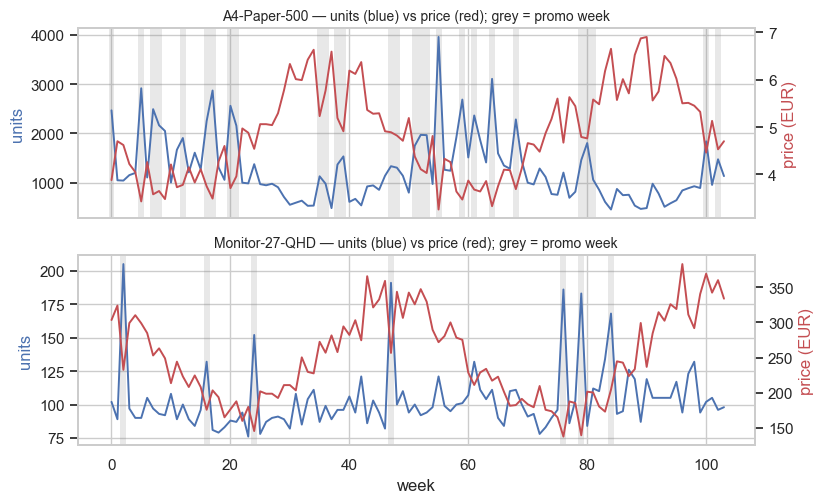

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(8.4, 5.2), sharex=True)
for ax, sku in zip(axes, ["A4-Paper-500", "Monitor-27-QHD"]):
    d = sales[sales.sku == sku]
    ax.plot(d.week, d.units, color="#4c72b0", lw=1.4, label="units")
    ax.set_ylabel("units", color="#4c72b0")
    ax2 = ax.twinx()
    ax2.plot(d.week, d.price, color="#c44e52", lw=1.4, label="price")
    ax2.set_ylabel("price (EUR)", color="#c44e52")
    ax2.grid(False)
    for w in d.loc[d.promo == 1, "week"]:
        ax.axvspan(w - 0.5, w + 0.5, color="grey", alpha=0.18, lw=0)
    ax.set_title(f"{sku} — units (blue) vs price (red); grey = promo week", fontsize=10)
axes[1].set_xlabel("week")
plt.tight_layout(); plt.show()

## 2. The naive elasticity — and why it is a lie

**Elasticity** is the percentage change in units for a 1 % change in price:

$$\varepsilon = \frac{\partial \ln q}{\partial \ln p}$$

It is negative (higher price, fewer units), and its magnitude is the whole story: |ε| = 3 means *"cut price 1 %, sell 3 % more"*; |ε| = 0.5 means *"cut price 1 %, sell only 0.5 % more"* — a discount that gives away margin for almost nothing.

The reason we model in **logs on both sides** is that the slope of `log(units) ~ log(price)` *is* the elasticity, directly, with no rescaling. One regression, read the coefficient, done. Which is exactly what makes the next cell so dangerous.

> 🚫 **Misconception — "I have two years of prices and volumes, so I can just regress one on the other."**
> You can, and it will hand you a tidy coefficient — often with three stars of significance. It will also be **wrong**, sometimes by a factor of two or more, and — worse — wrong in a *predictable direction*: toward zero. A price elasticity of −0.1 says "customers barely react, raise the price"; that is the most expensive sentence in this notebook, and the naive regression produces it on demand.

In [6]:
def naive_elasticity(sku):
    d = sales[sales.sku == sku]
    f = smf.ols("lq ~ lp", data=d).fit()
    return f.params["lp"], f.pvalues["lp"], f.rsquared

print(f"{'sku':16s} {'naive eps':>10} {'p-value':>9} {'R2':>6}   reading")
for sku in SKU_BOOK:
    e, pv, r2 = naive_elasticity(sku)
    reading = ("very elastic" if e < -2 else "moderately elastic" if e < -1
               else "barely reacts at all")
    print(f"{sku:16s} {e:>10.2f} {pv:>9.4f} {r2:>6.2f}   {reading}")

sku               naive eps   p-value     R2   reading
A4-Paper-500          -2.33    0.0000   0.87   very elastic
Toner-XL-Mono         -0.89    0.0000   0.56   barely reacts at all
Monitor-27-QHD        -0.12    0.1180   0.02   barely reacts at all


The truth planted in the data generator is **−3.20, −1.75 and −1.15**. The naive regression understated every single one:

- The paper's −2.33 is *significant, tidy and 27 % too small*. Nothing about the output warns you.
- The toner's −0.89 has crossed the line that matters — it puts |ε| **below 1**, which is the difference between "moderately elastic" and "the customer barely notices."
- The monitor's −0.12 has **p = 0.118 and R² = 0.02**. An analyst reading that off a summary table would write: *"no statistical evidence that price affects monitor demand."* The truth is an elasticity of −1.15, i.e. more than one-for-one.

That third case is the one to remember, because the failure does not look like a wrong number — it looks like an **absence of evidence**. Act on it and you tell the board that monitor demand is price-insensitive; in truth a big price rise costs you more volume than the margin it buys.

> ⚠️ **The dangerous kind of wrong.** Notice the bias runs *toward zero*, i.e. toward "customers don't care." Bias toward zero flatters every price increase and makes every discount look wasteful. If a naive elasticity ever tells you a product is inelastic, assume you are looking at your own pricing habits until you have ruled it out.

### 🔬 What actually happens: the price was not randomly assigned

An elasticity is a **causal** quantity — *"if we changed the price, and changed nothing else, what would happen to volume?"* — and a regression only recovers it when price moves for reasons unrelated to demand. Here is what actually generated our prices:

```text
                    ┌──────────────────┐
                    │  SEASON (autumn) │   ← the confounder
                    └────┬─────────┬───┘
          supplier costs │         │ customers are buying anyway
          tighten, and   │         │
          the merchant   │         │
          marks up       ▼         ▼
                      PRICE ↑    DEMAND ↑
                        └───?───────┘
                     the correlation we measure
```

Both arrows out of `SEASON` push **up**. So in the data, high prices come bundled with high demand — a *positive* contribution to the price/volume correlation, sitting on top of the true *negative* causal effect. The two partly cancel. What survives is an elasticity shrunk toward zero.

The promotions make it worse in the same direction: the flyer goes out in the **slow** weeks, so low prices come bundled with low seasonal demand. Same sign, same shrinkage.

```text
   TRUE effect of price on units   :  ──────────────►  strongly negative
   CONFOUND via season / promo slot:  ◄──────          positive
   ─────────────────────────────────────────────────────────────────
   WHAT THE NAIVE REGRESSION SEES  :  ────►            weakly negative
```

This has a name in econometrics — **price endogeneity**, or the *identification problem of the demand curve* — and it is the single reason companies with warehouses full of data still cannot tell you their own elasticities. It is the same disease as NB 23's post-outcome leakage and NB 26's unshifted rolling window: **the feature carries information about the outcome that arrives through the back door.**

📊 **See it in one chart.** Each dot is one week: log price against log units, coloured by how strong the season was. The dashed line is the naive fit. Follow the colours, not the cloud: within any single colour band the slope is steep and negative — but the bands themselves march up and to the right, and the naive line averages across them.

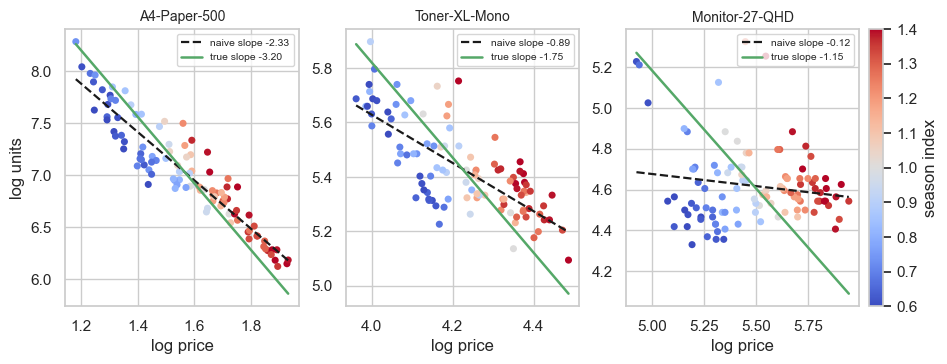

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12.2, 3.6))
for ax, sku in zip(axes, SKU_BOOK):
    d = sales[sales.sku == sku].copy()
    p = SKU_BOOK[sku]
    d["season"] = 1 + p["amp"] * np.sin(2 * np.pi * (d.week - p["phase"]) / 52)
    sc = ax.scatter(d.lp, d.lq, c=d.season, cmap="coolwarm", s=26, edgecolor="none")
    xs = np.linspace(d.lp.min(), d.lp.max(), 50)
    f = smf.ols("lq ~ lp", data=d).fit()
    ax.plot(xs, f.params["Intercept"] + f.params["lp"] * xs, "k--", lw=1.6,
            label=f"naive slope {f.params['lp']:.2f}")
    # the true slope, drawn through the cloud's centre for comparison
    ax.plot(xs, d.lq.mean() + p["eps"] * (xs - d.lp.mean()), color="#55a868", lw=1.8,
            label=f"true slope {p['eps']:.2f}")
    ax.set_title(sku, fontsize=10)
    ax.set_xlabel("log price"); ax.legend(fontsize=7.5, loc="upper right")
axes[0].set_ylabel("log units")
fig.colorbar(sc, ax=axes, label="season index", pad=0.01)
plt.show()

---

### ✋ Quick exercise (~2 min) — which way does the bias run?

The merchandiser at a *different* company has the opposite habit: they run their deepest promotions **during** the Christmas rush, when demand is highest, and hold list prices flat the rest of the year.

In their data, do low prices coincide with high or low seasonal demand? Will their naive elasticity be biased **toward zero** (too flat, like ours) or **away from zero** (too steep)? Compute the naive slope on the toy data below to check your reasoning.

```python
season = np.array([1.0, 1.0, 1.0, 1.6, 1.6, 1.0, 1.0, 1.0])   # weeks 4-5 are Christmas
price  = np.array([10., 10., 10., 8.0, 8.0, 10., 10., 10.])   # promo in the RUSH
```

In [8]:
# ✍️ Your turn 👇
season = np.array([1.0, 1.0, 1.0, 1.6, 1.6, 1.0, 1.0, 1.0])   # weeks 4-5 are Christmas
price  = np.array([10., 10., 10., 8.0, 8.0, 10., 10., 10.])   # promo in the RUSH
TRUE_EPS = -1.5
# Build units with the true elasticity AND the season, then fit log(units) ~ log(price):

<details>
<summary>✅ <b>Solution</b></summary>

```python
season = np.array([1.0, 1.0, 1.0, 1.6, 1.6, 1.0, 1.0, 1.0])
price  = np.array([10., 10., 10., 8.0, 8.0, 10., 10., 10.])
TRUE_EPS = -1.5
units = 100 * (price / 10) ** TRUE_EPS * season          # true effect x season
slope = np.polyfit(np.log(price), np.log(units), 1)[0]
print(f"true eps {TRUE_EPS:+.2f}  ->  naive slope {slope:+.2f}")
```

The naive slope comes out around **−3.6**, more than twice as steep as the true −1.5. Promoting *into* the rush bundles low prices with high demand, so the confound now pushes the correlation in the **same** direction as the causal effect and the estimate is biased **away from zero**.

The lesson is not "naive elasticities are too flat" — it is that the bias inherits its sign from *how your company sets prices*. Discount in the trough (our webshop) → too flat. Discount in the peak (this company) → too steep. Either way you have to model the reason price moved.
</details>

## 3. Identifying the demand curve — controls that earn their keep

We cannot re-run history as an experiment, so we do the next best thing: **put the confounders in the model**. If season and the promo flag are in the regression, the `lp` coefficient is estimated from whatever price variation is *left over* after season and promo are accounted for — and that leftover variation comes from the idiosyncratic supplier-cost shocks, which have nothing to do with customer demand.

Four controls, each doing a specific job:

| Control | Job it does |
|---|---|
| `sin1`, `cos1` | absorbs the annual seasonal wave in demand (NB 11's Fourier pair — smoother and cheaper than 52 week dummies) |
| `promo` | absorbs the **display effect**: the flyer, the endcap and the email sell units *at the same price*. Leave it out and the regression credits that lift to the price cut. |
| `week` | absorbs the underlying growth trend, so a rising volume trend is not attributed to price drift |

> 🧮 **Why the leftover variation identifies the elasticity.** Our prices are `cost × markup`, and unit cost carries an idiosyncratic shock that no customer can see. Cost shifts supply without shifting demand — the textbook definition of a valid **instrument**. Adding controls is the poor cousin of instrumental-variables estimation (Stretch B does the real thing), but when the confounders are few and observable it does the job.

In [9]:
SPEC       = "lq ~ lp + sin1 + cos1 + promo + week"   # the credible model
SPEC_NAIVE = "lq ~ lp"                                # section 2's mistake

fits = {sku: smf.ols(SPEC, data=sales[sales.sku == sku]).fit() for sku in SKU_BOOK}

rows = []
for sku, p in SKU_BOOK.items():
    f = fits[sku]
    lo, hi = f.conf_int().loc["lp"]
    rows.append({"sku": sku, "true_eps": p["eps"],
                 "naive_eps": round(naive_elasticity(sku)[0], 2),
                 "eps": round(f.params["lp"], 2), "ci_lo": round(lo, 2), "ci_hi": round(hi, 2),
                 "display_lift": f"{np.exp(f.params['promo']) - 1:.0%}",
                 "R2": round(f.rsquared, 3)})
elasticities = pd.DataFrame(rows).set_index("sku")
print(elasticities.to_string())

                true_eps  naive_eps   eps  ci_lo  ci_hi display_lift     R2
sku                                                                        
A4-Paper-500       -3.20      -2.33 -3.08  -3.28  -2.88          25%  0.984
Toner-XL-Mono      -1.75      -0.89 -1.80  -1.99  -1.60          15%  0.864
Monitor-27-QHD     -1.15      -0.12 -1.12  -1.32  -0.92          42%  0.856


**Every confidence interval now covers the truth** — and the `naive_eps` column is there to show what four controls were worth. On the monitor the estimate moves from −0.12 (indistinguishable from "price does not matter") to −1.12, whose interval [−1.32, −0.92] lies mostly on the elastic side of −1. That is the difference between a defensible price decision and a self-inflicted volume collapse.

The `display_lift` column is the other prize. It says that on promo weeks the paper sells ~25 % more **at the same price**, purely from being in the flyer — and the monitor a striking 42 % more. That volume does not belong to the price cut, and §6 is where it earns its own decision.

> 📏 **How to read an elasticity — and the trap.** A log-log coefficient of −1.80 means *"a 1 % price rise costs 1.8 % of units."* It is a **percentage-per-percentage** number, so it is unit-free: same value whether you price in euros or cents. Two ways people get this wrong:
> - Quoting it as **units per euro**. It is not. To get units, you need the level: at the toner's ~210 units a week and ε = −1.80, a 1 % rise (€0.69) costs ~4 units a week; the identical elasticity on a SKU selling 2,100 units costs ~37.
> - Reading it as **percentage points**. "Elasticity −1.8, so a 10 % price rise costs 18 % of volume" is the linear approximation; exactly, volume multiplies by `1.10 ** -1.8 = 0.842`, i.e. **−15.8 %**. The approximation is fine for 1 %, sloppy at 10 %, useless at 30 % — and price decisions are rarely 1 %. Always compute `(new/old) ** eps`.

### 🔮 Predict the output

We refit the toner three times, dropping one control at a time. Which omission moves the elasticity most — and in which direction?

```python
for label, spec in [("full",       "lq ~ lp + sin1 + cos1 + promo + week"),
                    ("no season",  "lq ~ lp + promo + week"),
                    ("no promo",   "lq ~ lp + sin1 + cos1 + week"),
                    ("no trend",   "lq ~ lp + sin1 + cos1 + promo")]:
    ...
```

Commit to an answer before running: does dropping `promo` make the elasticity look **more** negative or **less**? (Hint: the flyer lift is positive and lands on the same weeks as the low prices.)

In [10]:
# Predict first, then run.
d = sales[sales.sku == "Toner-XL-Mono"]
for label, spec in [("full",      "lq ~ lp + sin1 + cos1 + promo + week"),
                    ("no season", "lq ~ lp + promo + week"),
                    ("no promo",  "lq ~ lp + sin1 + cos1 + week"),
                    ("no trend",  "lq ~ lp + sin1 + cos1 + promo")]:
    f = smf.ols(spec, data=d).fit()
    print(f"{label:10s} eps = {f.params['lp']:+.2f}   R2 = {f.rsquared:.3f}")
print(f"{'truth':10s} eps = {SKU_BOOK['Toner-XL-Mono']['eps']:+.2f}")

full       eps = -1.80   R2 = 0.864
no season  eps = -0.90   R2 = 0.701
no promo   eps = -1.96   R2 = 0.823
no trend   eps = -1.80   R2 = 0.845
truth      eps = -1.75


<details>
<summary>💡 <b>Answer</b></summary>

Dropping `promo` makes the elasticity look **more negative** (−1.96 vs the full model's −1.80) — it *overstates* how much customers respond to price. The display lift happens on exactly the weeks the price was cut, so with no `promo` term to claim it, the regression hands that extra volume to the price cut. The price cut gets credit for the flyer's work.

Dropping `season` is by far the bigger error: −0.90, halving the true elasticity. That is §2's bias reappearing, and note it moves in the *opposite* direction.

The two omissions bias in **opposite directions**, which is worth sitting with: "add more controls" is not a monotone improvement, and an elasticity that happens to look right can be two large errors cancelling. The defence is not more controls, it is knowing *which* mechanisms generated your prices.

Dropping the trend barely matters here — 6 % annual growth over two years is a small effect next to the toner's ±26 % price range.
</details>

### Does the model actually predict? A time-honest check

An elasticity is not directly observable, so we cannot score it. What we *can* do is check whether the demand model it comes from forecasts weeks it has never seen — fit on the first 18 months, predict the last 6. We score only the **non-promo** weeks, because that is the regime a list-price decision lives in.

In [11]:
CUT = 78     # fit on weeks 0-77, test on 78-103
print(f"{'sku':16s} {'test wks':>8} {'MAPE':>7} {'flat-mean MAPE':>15} {'eps train':>10} {'eps full':>9}")
for sku in SKU_BOOK:
    d = sales[sales.sku == sku]
    train, test = d[d.week < CUT], d[(d.week >= CUT) & (d.promo == 0)]
    f_tr = smf.ols(SPEC, data=train).fit()
    pred = np.exp(f_tr.predict(test))
    mape = (abs(pred - test.units) / test.units).mean()
    flat = (abs(train.units.mean() - test.units) / test.units).mean()
    print(f"{sku:16s} {len(test):>8d} {mape:>7.1%} {flat:>15.1%} "
          f"{f_tr.params['lp']:>10.2f} {fits[sku].params['lp']:>9.2f}")

sku              test wks    MAPE  flat-mean MAPE  eps train  eps full
A4-Paper-500           21    4.8%           99.7%      -3.03     -3.08
Toner-XL-Mono          25    5.1%           14.4%      -1.79     -1.80
Monitor-27-QHD         24    6.5%           10.3%      -1.09     -1.12


5–7 % MAPE against a flat-mean baseline that is 10–100 % off, and elasticities that move by at most 0.05 when six months of data are withheld. That is the licence to keep going: the model is not merely *fitting* the history, it **predicts held-out weeks at prices it was not trained on**. If this check had failed, nothing below would be worth printing.

> ⚠️ **What this check does not prove.** It shows the model extrapolates well *within* the price range it has seen. It says nothing about €400 monitors. Hold that thought until §5.

---

### ✋ Quick exercise (~2 min) — from elasticity to a volume forecast

Marketing wants to know what a **7 % list-price increase** on the toner would do to volume, and they want units, not percentages. The toner sells about **210 units** in an average non-promo week.

Use the estimated elasticity from `elasticities` to compute the exact volume multiplier and the units lost — and compare it with the sloppy linear answer ("−1.8 × 7 % = −12.6 %").

```python
eps  = elasticities.loc["Toner-XL-Mono", "eps"]
base_units = 210
hike = 0.07
```

In [12]:
# ✍️ Your turn 👇
eps = elasticities.loc["Toner-XL-Mono", "eps"]
base_units = 210
hike = 0.07
# Exact multiplier, units lost, and the linear approximation for comparison:

<details>
<summary>✅ <b>Solution</b></summary>

```python
eps = elasticities.loc["Toner-XL-Mono", "eps"]
base_units, hike = 210, 0.07
mult   = (1 + hike) ** eps                  # exact
approx = 1 + eps * hike                     # the linear shortcut
print(f"eps {eps:+.2f} | exact multiplier {mult:.3f} ({mult - 1:+.1%}, "
      f"{base_units * (mult - 1):+.0f} units)")
print(f"          linear approx {approx:.3f} ({approx - 1:+.1%}, "
      f"{base_units * (approx - 1):+.0f} units)")
print(f"the shortcut overstates the volume loss by "
      f"{abs(base_units * (approx - mult)):.0f} units/week")
```

Exact: volume multiplies by `1.07 ** -1.80 ≈ 0.885`, so **−11.5 %**, about −24 units a week. The linear shortcut says −12.6 % / −26 units. Only ~2 units apart here — but the gap grows with the square of the price change, so on a 30 % move the shortcut is out by a fifth. Use `(1 + hike) ** eps` and never think about it again.
</details>

## 4. From elasticity to a price — the rule you can do in your head

We have a credible elasticity. Now the model has to become money, which in this module means a formula you can defend in a meeting.

Weekly profit at price *p*, with unit cost *c* and constant-elasticity demand $q(p) = A p^{\varepsilon}$:

$$\pi(p) = (p - c) \, A \, p^{\varepsilon}$$

Differentiate, set to zero, and the *A* cancels — the profit-maximizing price depends only on **cost and elasticity**:

$$\boxed{p^{*} = c \cdot \frac{\varepsilon}{1 + \varepsilon}} \qquad \text{(valid only when } \varepsilon < -1\text{)}$$

This is the **inverse-elasticity rule** (a.k.a. the Lerner markup). Read it as: the more elastic your customers, the thinner your markup. At ε = −3 the optimal markup is 1.5× cost; at ε = −1.5 it is 3× cost.

### The one-line version — should this price go up or down?

You rarely need the optimal price. You need the **direction**. Take the log-derivative of profit:

$$\frac{d \ln \pi}{d \ln p} = \frac{p}{p - c} + \varepsilon \; > 0 \iff |\varepsilon| < \frac{1}{\text{CM}}, \quad \text{CM} = \frac{p - c}{p}$$

$$\boxed{\text{Raise the price iff } |\varepsilon| \cdot \text{CM} < 1}$$

**Compare your elasticity to the reciprocal of your contribution margin.** A 33 %-margin product tolerates elasticity up to −3.0 before a price rise stops paying; a 70 %-margin product only up to −1.4. That is why software companies fret about elasticity and commodity distributors fret about cost — and it is the pricing twin of NB 23's break-even threshold `p* = cost / (s · CLV)`: one line, derived from costs, that turns a model output into *act or don't*.

In [13]:
rows = []
for sku in SKU_BOOK:
    eps = fits[sku].params["lp"]
    lo, hi = fits[sku].conf_int().loc["lp"]
    cost, cur = SCENARIO[sku]
    cm = (cur - cost) / cur
    rows.append({"sku": sku, "eps": round(eps, 2), "cost": cost, "price_now": cur,
                 "CM": f"{cm:.0%}", "one_over_CM": round(1 / cm, 2),
                 "headroom": round(abs(eps) * cm, 2),
                 "verdict": "RAISE" if abs(eps) * cm < 1 else "CUT",
                 "headroom_ci": f"{abs(hi) * cm:.2f}–{abs(lo) * cm:.2f}"})
decision = pd.DataFrame(rows).set_index("sku")
print(decision.to_string())
print("\nheadroom = |eps| x CM.  < 1 -> raising price adds profit.  > 1 -> cutting does.")

                 eps   cost  price_now   CM  one_over_CM  headroom verdict headroom_ci
sku                                                                                   
A4-Paper-500   -3.08    3.3       4.99  34%         2.95      1.04     CUT   0.97–1.11
Toner-XL-Mono  -1.80   39.0      69.00  43%         2.30      0.78   RAISE   0.70–0.86
Monitor-27-QHD -1.12  168.0     249.00  33%         3.07      0.36   RAISE   0.30–0.43

headroom = |eps| x CM.  < 1 -> raising price adds profit.  > 1 -> cutting does.


Three products, three different situations — and this is where a pricing project stops being a regression and starts being a judgement call:

- **Toner — headroom 0.78, a clear RAISE.** |ε| = 1.80 against a tolerance of 2.30, and the whole confidence interval stays below 1. The margin is fat, the customers are locked into the printer fleet, and the price is too low.
- **Monitor — headroom 0.36, an emphatic RAISE.** Suspiciously emphatic. Park it; §5 explains why this is the number *not* to act on.
- **Paper — headroom 1.04, a marginal CUT.** But look at the CI: **0.97–1.11**, straddling 1.00. The data cannot tell us whether the paper price should go up or down. That is a finding, not a failure.

In [14]:
def optimal_price(eps, cost):
    """Inverse-elasticity rule. Returns inf when demand is inelastic (|eps| <= 1),
    where profit rises without bound in the model and the formula has no answer."""
    return cost * eps / (1 + eps) if eps < -1 else np.inf

def scenario_frame(price, n_weeks=13, promo=0, start=WEEKS):
    """A synthetic future quarter at a fixed price, shaped for `fit.predict`."""
    w = np.arange(start, start + n_weeks)
    fr = pd.DataFrame({"week": w, "week_of_year": w % 52 + 1, "promo": promo})
    fr["sin1"] = np.sin(2 * np.pi * fr.week_of_year / 52)
    fr["cos1"] = np.cos(2 * np.pi * fr.week_of_year / 52)
    fr["lp"] = np.log(price)
    return fr

def quarter_margin(price, sku):
    """Model-predicted contribution margin over the next 13 weeks at `price`."""
    cost = SCENARIO[sku][0]
    q = np.exp(fits[sku].predict(scenario_frame(price)))
    return float(((price - cost) * q).sum()), float(q.sum())

print(f"{'sku':16s} {'eps':>6} {'p_now':>8} {'p*':>10} {'change':>8} {'observed range':>20}")
for sku in SKU_BOOK:
    eps = fits[sku].params["lp"]; cost, cur = SCENARIO[sku]
    star = optimal_price(eps, cost)
    d = sales[sales.sku == sku]
    print(f"{sku:16s} {eps:>6.2f} {cur:>8.2f} {star:>10.2f} {star / cur - 1:>+8.1%} "
          f"{d.price.min():>9.2f}–{d.price.max():<9.2f}")

sku                 eps    p_now         p*   change       observed range
A4-Paper-500      -3.08     4.99       4.89    -2.1%      3.26–6.90     
Toner-XL-Mono     -1.80    69.00      88.02   +27.6%     52.56–88.78    
Monitor-27-QHD    -1.12   249.00    1553.94  +524.1%    137.56–382.89   


📈 **The profit curve, drawn.** For the toner: model-predicted margin over the next 13 weeks at every candidate price, with revenue on the same axes for contrast. The shaded band is the **price range we have actually charged** — the only region where the demand model rests on evidence.

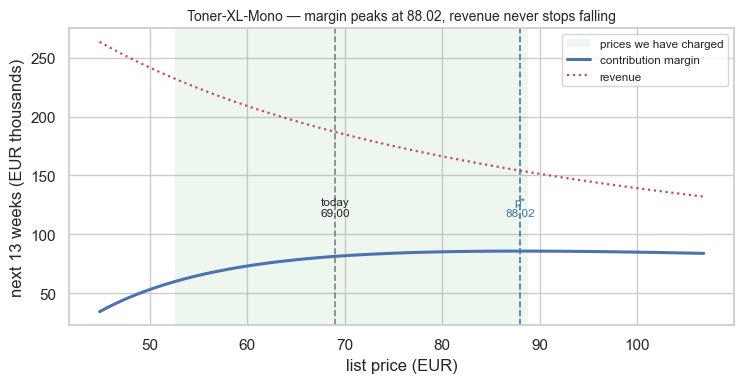

grid argmax 88.10 vs formula 88.02  (they agree)
margin      81,296 ->     85,798 EUR/quarter  (+5.5%)
units        2,710 ->      1,750 per quarter    (-35.4%)


In [15]:
sku = "Toner-XL-Mono"
cost, cur = SCENARIO[sku]
grid = np.arange(cur * 0.65, cur * 1.55, 0.25)
marg = np.array([quarter_margin(p, sku)[0] for p in grid])
q    = np.array([quarter_margin(p, sku)[1] for p in grid])
rev  = grid * q
star = optimal_price(fits[sku].params["lp"], cost)
lo, hi = sales.loc[sales.sku == sku, "price"].agg(["min", "max"])

fig, ax = plt.subplots(figsize=(7.6, 4))
ax.axvspan(lo, hi, color="#55a868", alpha=0.10, lw=0, label="prices we have charged")
ax.plot(grid, marg / 1000, lw=2.2, color="#4c72b0", label="contribution margin")
ax.plot(grid, rev / 1000, lw=1.6, color="#c44e52", ls=":", label="revenue")
ax.axvline(cur, color="grey", ls="--", lw=1.2)
ax.axvline(star, color="#4c72b0", ls="--", lw=1.2)
ax.annotate(f"today\n{cur:.2f}", (cur, ax.get_ylim()[1] * 0.42), ha="center", fontsize=8.5)
ax.annotate(f"p*\n{star:.2f}", (star, ax.get_ylim()[1] * 0.42), ha="center", fontsize=8.5,
            color="#4c72b0")
ax.set_xlabel("list price (EUR)"); ax.set_ylabel("next 13 weeks (EUR thousands)")
ax.set_title(f"{sku} — margin peaks at {star:.2f}, revenue never stops falling", fontsize=10)
ax.legend(fontsize=8.5); plt.tight_layout(); plt.show()

m_now, u_now = quarter_margin(cur, sku)
m_new, u_new = quarter_margin(star, sku)
print(f"grid argmax {grid[marg.argmax()]:.2f} vs formula {star:.2f}  (they agree)")
print(f"margin  {m_now:>10,.0f} -> {m_new:>10,.0f} EUR/quarter  ({m_new / m_now - 1:+.1%})")
print(f"units   {u_now:>10,.0f} -> {u_new:>10,.0f} per quarter    ({u_new / u_now - 1:+.1%})")

Two things in that output deserve a meeting of their own.

**The numeric grid and the closed-form formula agree.** Good — the algebra was not a trick, and when your demand model is something a formula cannot differentiate (a gradient-boosted model, a demand curve with a kink), the grid still works. Always be able to do it both ways.

**Volume falls by a third and profit rises.** That is the sentence that makes pricing projects politically hard. The recommendation ships fewer cartridges, so the sales team's volume bonus shrinks, the warehouse looks quiet, and the revenue line — the dotted red curve, which under |ε| > 1 falls monotonically as price rises — goes *down*. Only the margin line goes up. If you cannot show all three curves and name which one the company is actually paid on, the recommendation will not survive contact with the org.

> ⚠️ **Revenue-maximizing and profit-maximizing prices are different questions.** With |ε| > 1 revenue always rises as price *falls*, so on any price grid the revenue-optimal price is the grid's floor — there is no interior revenue optimum at all. "Maximize revenue" is not a pricing objective; it is a growth objective that happens to be spelled like one. Decide which you are optimizing *before* you fit anything.

---

### ✋ Quick exercise (~2 min) — price a fourth SKU

The category manager adds `Cable-USBC-2m`: unit cost **€4.10**, current list **€12.90**, and a previous study put its elasticity at **−2.10**.

Should the price go up or down? By how much? Use the headroom rule for the direction and the inverse-elasticity rule for the target.

```python
cost, cur, eps = 4.10, 12.90, -2.10
```

In [16]:
# ✍️ Your turn 👇
cost, cur, eps = 4.10, 12.90, -2.10
# Contribution margin, headroom = |eps| x CM, verdict, and p*:

<details>
<summary>✅ <b>Solution</b></summary>

```python
cost, cur, eps = 4.10, 12.90, -2.10
cm = (cur - cost) / cur
headroom = abs(eps) * cm
star = optimal_price(eps, cost)
print(f"CM {cm:.1%} | 1/CM {1 / cm:.2f} | headroom {headroom:.2f} -> "
      f"{'RAISE' if headroom < 1 else 'CUT'}")
print(f"p* = {star:.2f} ({star / cur - 1:+.1%} vs today)")
```

CM is 68 %, so the tolerance `1/CM` is only **1.47** — and |ε| = 2.10 is well past it. Headroom **1.43 > 1**, so the verdict is **CUT**, and `p* = 4.10 × 2.10/1.10 = €7.83`, a 39 % reduction.

This is the fat-margin trap in one line: a 68 % margin feels like room to relax, but it means most of the price is markup, so *every* unit you lose costs you a lot of profit — and a moderately elastic customer base makes a high markup indefensible. High margin plus elastic demand is the classic over-priced accessory.

Would you actually cut a cable's price 39 % on one old elasticity study? No — see §5. But you would put it on the list of things to test.
</details>

## 5. Guardrails — the confidence interval, the support, and the flat peak

We have three point estimates and three prices. Shipping them as-is would be the classic analytics failure, so here are the three guardrails that turn a number into a recommendation.

### Guardrail 1 — propagate the uncertainty, don't quote the point

`p* = c·ε/(1+ε)` is a *very* non-linear function of ε, and it has a pole at ε = −1. A confidence interval on ε that looks harmless can map to an interval on p* that spans an order of magnitude. Bootstrap it and look.

In [17]:
def bootstrap_eps(sku, n=400, seed=0):
    d = sales[sales.sku == sku].reset_index(drop=True)
    r = np.random.default_rng(seed)
    out = []
    for _ in range(n):
        out.append(smf.ols(SPEC, data=d.iloc[r.integers(0, len(d), len(d))]).fit().params["lp"])
    return np.array(out)

boot = {sku: bootstrap_eps(sku) for sku in SKU_BOOK}
print(f"{'sku':16s} {'eps p5':>8} {'p50':>7} {'p95':>7} {'P(|eps|<1)':>11} "
      f"{'p* p5':>9} {'p* p50':>9} {'p* p95':>11}")
for sku, es in boot.items():
    cost = SCENARIO[sku][0]
    inelastic = (es > -1).mean()
    fin = es[es < -1]
    ps = cost * fin / (1 + fin)
    print(f"{sku:16s} {np.percentile(es, 5):>8.2f} {np.median(es):>7.2f} "
          f"{np.percentile(es, 95):>7.2f} {inelastic:>11.1%} "
          f"{np.percentile(ps, 5):>9.2f} {np.median(ps):>9.2f} {np.percentile(ps, 95):>11.2f}")

sku                eps p5     p50     p95  P(|eps|<1)     p* p5    p* p50      p* p95
A4-Paper-500        -3.26   -3.09   -2.90        0.0%      4.76      4.88        5.03
Toner-XL-Mono       -1.94   -1.79   -1.65        0.0%     80.60     88.11       98.80
Monitor-27-QHD      -1.27   -1.13   -0.98        8.2%    784.63   1363.13    11694.59


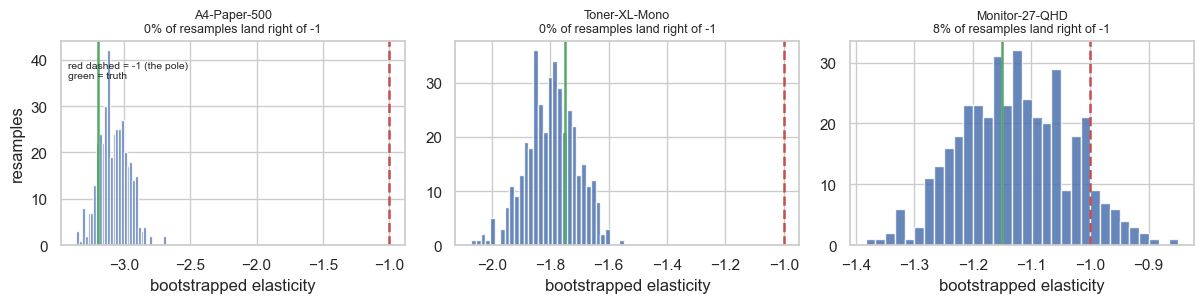

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(12.2, 3.2))
for ax, (sku, es) in zip(axes, boot.items()):
    ax.hist(es, bins=32, color="#4c72b0", alpha=0.85)
    ax.axvline(-1, color="#c44e52", lw=1.8, ls="--")
    ax.axvline(SKU_BOOK[sku]["eps"], color="#55a868", lw=1.8)
    ax.set_title(f"{sku}\n{(es > -1).mean():.0%} of resamples land right of -1", fontsize=9)
    ax.set_xlabel("bootstrapped elasticity")
axes[0].set_ylabel("resamples")
axes[0].text(0.02, 0.9, "red dashed = -1 (the pole)\ngreen = truth", transform=axes[0].transAxes,
             fontsize=7.5, va="top")
plt.tight_layout(); plt.show()

The paper and the toner are fine: tight elasticity distributions, and `p*` intervals of about ±3 % and −9 %/+12 % respectively — narrow enough to act on.

The monitor is a different animal. About **8 % of resamples put ε on the wrong side of −1**, where the inverse-elasticity rule returns infinity, and among the rest `p*` runs from roughly €785 to €11,700. The honest summary of the monitor analysis is: *"our best estimate is that monitor demand is slightly elastic, and we cannot tell you the profit-maximizing price to within a factor of fifteen."*

### Guardrail 2 — never extrapolate past the prices you have charged

The monitor's point estimate says **€1,554** against a list price of €249. Before dismissing it: in this notebook's generator, demand really *is* constant-elasticity all the way up, so €1,554 genuinely is the simulation's profit-maximizing price. The formula is not broken and the algebra is not wrong.

It is the **model** that is wrong outside the data. Real monitor demand does not obey a power law up to €1,554 — somewhere around €400 the customer buys a competitor's panel and your elasticity goes to −∞. We fitted a curve on prices between €138 and €383; asking it about €1,554 is asking a question the data cannot hear.

> 🧭 **The rule.** Trust a demand model inside its **support** and a short distance beyond — a common convention is the observed range plus ~10 %. Outside that, the model is an opinion in formula clothing. A boundary solution ("the optimum is at the edge of my grid") is not an answer; it is a **request for an experiment**.

### Guardrail 3 — near the optimum, profit is flat

The paper's headroom CI straddles 1.00, so the model cannot even sign the recommendation. Ask what that indecision *costs* — and, at the other end, what the monitor's confident-looking number is actually made of.

In [19]:
print(f"{'sku':16s} {'p_now':>7} {'p_rec':>8} {'basis':>10} "
      f"{'margin now':>12} {'margin rec':>12} {'gain':>8} {'gain/yr':>10}")
memo = []
for sku in SKU_BOOK:
    eps = fits[sku].params["lp"]; cost, cur = SCENARIO[sku]
    star = optimal_price(eps, cost)
    smax = sales.loc[sales.sku == sku, "price"].max() * 1.10   # support + 10 %
    p_rec, basis = (star, "formula") if star <= smax else (smax, "SUPPORT CAP")
    m_now, _ = quarter_margin(cur, sku)
    m_rec, _ = quarter_margin(p_rec, sku)
    memo.append((sku, cur, p_rec, basis, m_now, m_rec))
    print(f"{sku:16s} {cur:>7.2f} {p_rec:>8.2f} {basis:>10} {m_now:>12,.0f} {m_rec:>12,.0f} "
          f"{m_rec / m_now - 1:>+8.1%} {(m_rec - m_now) * 4:>10,.0f}")

sku                p_now    p_rec      basis   margin now   margin rec     gain    gain/yr
A4-Paper-500        4.99     4.89    formula       17,482       17,506    +0.1%         93
Toner-XL-Mono      69.00    88.02    formula       81,296       85,798    +5.5%     18,005
Monitor-27-QHD    249.00   421.18 SUPPORT CAP      124,200      215,341   +73.4%    364,564


⚠️ **Look hard at the monitor row before you enjoy it.** `SUPPORT CAP` means the formula's answer (€1,554) was overruled and replaced by the edge of the evidence — the highest price we have charged, plus 10 %. The table then dutifully reports **+73 % margin, €365k a year**, which is by far the biggest number in this notebook and the one you must not put in a deck.

It is a **boundary solution**: the optimum sits at the edge of the search region, which means the region — not the data — chose the answer. Push the cap out and the "gain" grows; the model will happily promise more margin at every price you allow it to consider, because a constant-elasticity curve with |ε| barely above 1 never turns over inside any plausible range. Reporting the number at a boundary as if it were an optimum is one of the most common ways an analysis becomes a fiction. The row is in the table so you can see it being **rejected**, not adopted.

**And at the other extreme, the paper's recommended cut is worth 0.1 % of its margin — €24 a quarter, €93 a year, on a €17,500 quarterly base.** That is not a decision, it is rounding error, and it is not an accident: profit curves are *flat near their peak* (the derivative is zero there, by construction). Being 3 % off the optimal price typically costs a fraction of a percent of profit. Which cuts both ways:

- **Good news:** you do not need a precise elasticity to capture most of the available money. Getting the *direction* right on a badly-priced product beats getting the third decimal right on a well-priced one.
- **The catch:** the same flatness means the paper's data will never resolve this question. €4.89 versus €4.99 is also below the granularity of a real **price ladder** — retail prices live on .49/.95/.99 endings for good behavioural reasons, and the nearest rung to €4.89 is €4.95. Spend the analyst hours on the toner instead.

### The memo

| SKU | Verdict | Why | Next step |
|---|---|---|---|
| `A4-Paper-500` | **HOLD at €4.99** | Headroom CI straddles 1.00 — direction unidentified; the model's own gain is €24/quarter | Nothing. Revisit if unit cost moves >5 % |
| `Toner-XL-Mono` | **RAISE to €88** (+28 %) | Headroom 0.78, whole CI below 1; +5.5 % margin, ≈ +€18k/year; and we have sold at €88.78 before, so this is inside the evidence | Stage it: €69 → €79 for a quarter, re-estimate, then €88. Warn sales that units fall ~35 % |
| `Monitor-27-QHD` | **TEST, don't set** | Best estimate says raise, but `p*` is unidentifiable to within a factor of 15 and lies 4× beyond the highest price we have ever charged; the capped figure is a boundary artefact | A randomized price test at €269/€289 for 8 weeks; re-estimate on data that was *designed* to answer this |

That third row is the one that separates an analyst from a spreadsheet: the deliverable for the monitor is **an experiment**, not a price. Stretch C sizes it.

---

### ✋ Quick exercise (~2 min) — how flat is flat?

Quantify Guardrail 3 for the toner: what does the margin curve lose if you mis-set the price by ±5 % and ±15 % around `p*`? Use `quarter_margin`.

```python
star = optimal_price(fits["Toner-XL-Mono"].params["lp"], SCENARIO["Toner-XL-Mono"][0])
```

In [20]:
# ✍️ Your turn 👇
star = optimal_price(fits["Toner-XL-Mono"].params["lp"], SCENARIO["Toner-XL-Mono"][0])
# Margin at p* and at p* x (1 +/- 0.05), (1 +/- 0.15) -- as a % of the peak:

<details>
<summary>✅ <b>Solution</b></summary>

```python
sku = "Toner-XL-Mono"
star = optimal_price(fits[sku].params["lp"], SCENARIO[sku][0])
peak, _ = quarter_margin(star, sku)
for off in (-0.15, -0.05, 0.0, 0.05, 0.15):
    m, _ = quarter_margin(star * (1 + off), sku)
    print(f"price {star * (1 + off):7.2f} ({off:+.0%})  margin {m:>10,.0f}  "
          f"{m / peak - 1:+.2%} vs peak")
```

±5 % off the optimal price costs about **0.2 %** of margin; ±15 % costs between **1.2 % and 2.2 %**. And the loss is asymmetric — at −15 % you give up 2.17 % against 1.24 % at +15 %, because being too *cheap* surrenders margin on every single unit while being too expensive only surrenders the units you lose.

Compare that with the **+5.5 %** the toner gains by moving from €69 to €88 and the priority becomes obvious: the money is in fixing prices that are *far* from optimal, not in polishing ones that are close. This is also the honest defence of a crude elasticity — if your estimate is off by 20 %, `p*` moves a few percent and you still capture almost all of the gain.
</details>

## 6. Was the promotion worth it? The break-even discount

List prices change once a year. **Promotions happen every week**, they are the biggest lever most commercial teams touch, and they are almost never evaluated properly. The usual evaluation is *"we sold 2.1× the units"* — which is a fact about volume, and volume is not the objective.

Here is the whole calculation. Discount by *d*, and per baseline unit you were selling anyway:

- margin per unit falls from `p − c` to `(1 − d)p − c`
- volume multiplies by some *M*

The promotion pays iff `((1−d)p − c) · M ≥ p − c`, i.e.

$$\boxed{M \ge M^{*} = \frac{p - c}{(1 - d)p - c}}$$

and, translating the required multiplier into an elasticity via `M = (1−d)^ε`:

$$\varepsilon^{*} = \frac{\ln M^{*}}{\ln(1 - d)}$$

**You must be at least this elastic for the discount to pay.** That is the pricing twin of NB 23's break-even threshold and NB 26's critical ratio — the third verse of the module's cost song.

The number that shocks people is how fast `M*` explodes. On the paper, `(1−d)p` approaches unit cost as *d* grows, so the denominator collapses: a 10 % discount needs 1.4× the volume, a 25 % discount needs **3.8×**. Thin margins cannot afford deep discounts, at any elasticity.

In [21]:
def required_multiplier(price, cost, d):
    net = (1 - d) * price
    return np.inf if net <= cost else (price - cost) / (net - cost)

rows = []
for sku in SKU_BOOK:
    cost, price = SCENARIO[sku]
    eps, disp = fits[sku].params["lp"], fits[sku].params["promo"]
    for d in (0.10, 0.15, 0.20, 0.25):
        need = required_multiplier(price, cost, d)
        promo_mult = (1 - d) ** eps * np.exp(disp)     # price effect x display effect
        perm_mult  = (1 - d) ** eps                    # price effect only
        rows.append({"sku": sku, "discount": f"{d:.0%}",
                     "need_M": round(need, 2),
                     "eps_star": round(np.log(need) / np.log(1 - d), 2),
                     "promo_M": round(promo_mult, 2),
                     "promo": "PAYS" if promo_mult >= need else "loses",
                     "perm_M": round(perm_mult, 2),
                     "permanent_cut": "PAYS" if perm_mult >= need else "loses"})
promo_table = pd.DataFrame(rows)
print(promo_table.to_string(index=False))

           sku discount  need_M  eps_star  promo_M promo  perm_M permanent_cut
  A4-Paper-500      10%    1.42     -3.32     1.73  PAYS    1.38         loses
  A4-Paper-500      15%    1.80     -3.60     2.06  PAYS    1.65         loses
  A4-Paper-500      20%    2.44     -4.00     2.48  PAYS    1.99         loses
  A4-Paper-500      25%    3.82     -4.66     3.03 loses    2.42         loses
 Toner-XL-Mono      10%    1.30     -2.48     1.39  PAYS    1.21         loses
 Toner-XL-Mono      15%    1.53     -2.60     1.54  PAYS    1.34         loses
 Toner-XL-Mono      20%    1.85     -2.76     1.72 loses    1.49         loses
 Toner-XL-Mono      25%    2.35     -2.97     1.93 loses    1.68         loses
Monitor-27-QHD      10%    1.44     -3.49     1.59  PAYS    1.13         loses
Monitor-27-QHD      15%    1.86     -3.80     1.70 loses    1.20         loses
Monitor-27-QHD      20%    2.60     -4.28     1.82 loses    1.28         loses
Monitor-27-QHD      25%    4.32     -5.09     1.96 l

Read the last two columns side by side, because they are the punchline of the section.

**The same discount can pay as a promotion and lose as a list-price cut.** A 15 % promo on the paper delivers 2.06× — comfortably past the 1.80× it needs — and pays. A *permanent* 15 % cut to €4.24 delivers only 1.65× and loses. Nothing about the customers changed. What changed is that the promo week came with the flyer, the endcap and the email, and the **display lift** (+25 % at the same price) is not part of the price effect. Make the price cut permanent and you keep the price effect and lose the display effect — which, on this SKU, is exactly the difference between paying and not.

Across all three SKUs, **every permanent cut at the depths shown loses** — 10 % is already too deep for all three. That is not a coincidence: these products' headroom values were all ≤ 1.04, so §4 already told us none of them wants a materially lower price. (The paper's headroom of 1.04 does buy it a *sliver*: Practice 2 finds permanent cuts up to ≈4 % pay, which is exactly §4's €4.89 recommendation. A sliver is not a promotion.)

> ⚠️ **The mirror-image error.** Estimating an elasticity on promotion weeks and applying it to list-price strategy is the most common analytical error in retail pricing, and it is measurable here: the model that omits the `promo` control returns **−1.96** for the toner instead of −1.80, because it credits the flyer to the price cut. Promo elasticity is not price elasticity. Practice exercise 3 lets you watch the mistake pay off in a slide deck and lose money in the P&L.

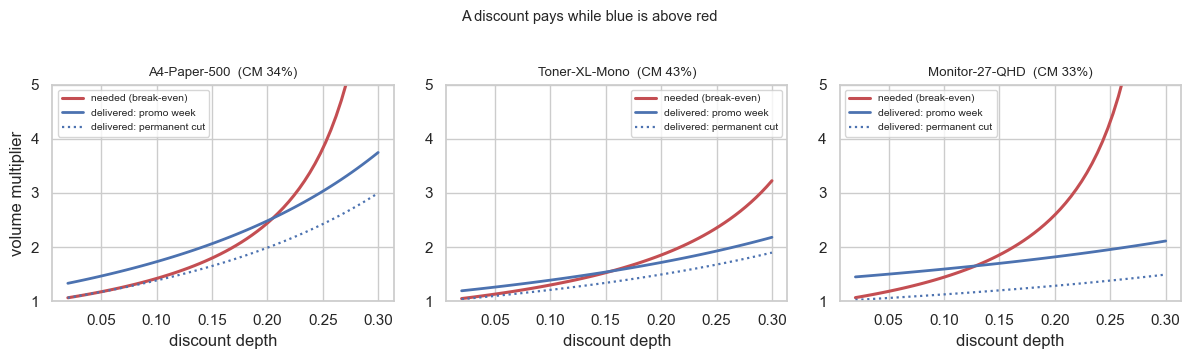

In [22]:
depths = np.linspace(0.02, 0.30, 60)
fig, axes = plt.subplots(1, 3, figsize=(12.2, 3.5))
for ax, sku in zip(axes, SKU_BOOK):
    cost, price = SCENARIO[sku]
    eps, disp = fits[sku].params["lp"], fits[sku].params["promo"]
    need = np.array([required_multiplier(price, cost, d) for d in depths])
    ax.plot(depths, need, color="#c44e52", lw=2.2, label="needed (break-even)")
    ax.plot(depths, (1 - depths) ** eps * np.exp(disp), color="#4c72b0", lw=2,
            label="delivered: promo week")
    ax.plot(depths, (1 - depths) ** eps, color="#4c72b0", lw=1.6, ls=":",
            label="delivered: permanent cut")
    ax.set_ylim(1, 5); ax.set_xlabel("discount depth")
    ax.set_title(f"{sku}  (CM {(price - cost) / price:.0%})", fontsize=9.5)
    ax.legend(fontsize=7.5)
axes[0].set_ylabel("volume multiplier")
plt.suptitle("A discount pays while blue is above red", fontsize=10.5, y=1.02)
plt.tight_layout(); plt.show()

The blue line crosses the red one at the deepest discount that still pays — the paper's flyer can go to ~20 %, the toner's to ~15 %, the monitor's to ~13 %. The dotted line, permanent cuts, sits under the red line across almost the whole range (Practice 2 pins the crossings down to the decimal).

### The retrospective: what last year's promo calendar actually did

Forward-looking rules are easy to argue with. Let us settle last year's promotions instead. For each of the 42 promo weeks we ask the demand model what would have happened at **list price, with no flyer**, and difference the margins.

In [23]:
rows = []
for sku in SKU_BOOK:
    d = sales[sales.sku == sku]
    promo_weeks = d[d.promo == 1].copy()
    counterfactual = promo_weeks.assign(promo=0, lp=np.log(promo_weeks.list_price))
    q_base = np.exp(fits[sku].predict(counterfactual))

    m_actual = float(((promo_weeks.price - promo_weeks.unit_cost) * promo_weeks.units).sum())
    m_base   = float(((counterfactual.list_price - counterfactual.unit_cost) * q_base).sum())
    rows.append({"sku": sku, "promo_weeks": len(promo_weeks),
                 "avg_discount": f"{(1 - promo_weeks.price / promo_weeks.list_price).mean():.1%}",
                 "units_sold": int(promo_weeks.units.sum()),
                 "units_baseline": round(float(q_base.sum())),
                 "margin_actual": round(m_actual), "margin_baseline": round(m_base),
                 "incremental": round(m_actual - m_base)})
promo_pnl = pd.DataFrame(rows).set_index("sku")
print(promo_pnl.to_string())
print(f"\nPortfolio over 2 years: {promo_pnl.incremental.sum():+,.0f} EUR")

                promo_weeks avg_discount  units_sold  units_baseline  margin_actual  margin_baseline  incremental
sku                                                                                                              
A4-Paper-500             28        12.8%       57174           29580          51924            44968         6956
Toner-XL-Mono             7        10.7%        2134            1516          47413            44821         2592
Monitor-27-QHD            7        21.4%        1217             651          28267            48439       -20172

Portfolio over 2 years: -10,624 EUR


Two of the three promo programmes made money and the third lost more than both made:

- **Paper: +€7.0k.** 28 weeks of shallow (≈13 %) discounts on an elastic commodity nearly doubled the units. This is what promotions are *for*.
- **Toner: +€2.6k.** Seven weeks at ≈11 % — small, positive, and consistent with the break-even table saying 10 % pays and 15 % does not.
- **Monitor: −€20.2k.** Seven weeks at ≈21 % on a barely-elastic, thin-margin, high-ticket item. Volume rose 87 % and margin fell 42 %. Every unit of that "success" was sold at a margin too thin to be worth selling.

The portfolio number is **−€10.6k over two years**, and it is the sort of finding that only ever appears when someone insists on a counterfactual. A dashboard reporting promo-week revenue would have shown all three programmes as triumphs.

> ⚠️ **How honest is that counterfactual?** It is model-based, not experimental — we asked a regression fitted partly on these same weeks what would have happened. Two things make it defensible rather than circular: the model predicts **held-out** non-promo weeks to 5–7 % MAPE (§3), and each SKU's `promo` coefficient is pooled across all of its promo weeks, so no single week drives its own baseline. What would make it *airtight* is a holdout: leave the flyer out in a random subset of weeks or regions and compare. That is a two-line change to a promo calendar and almost nobody does it.
>
> Two real effects our counterfactual still ignores, both of which make promotions look **better** than they are: **pull-forward** (a B2B customer who buys 40 reams on promo does not buy again next month, so part of the "incremental" volume is stolen from future weeks) and **subsidising the loyal** (the customers who would have paid list get the discount too — the pricing cousin of NB 23's "sleeping dogs"). A promo that looks marginally positive here is probably negative once both are priced.

> 🎛️ **Try it live.** Drag the sliders to feel the trade-off: pick a SKU, move the price, watch the margin curve and where you sit on it. (Runs without `ipywidgets` too — you just get the default view.)

In [24]:
# Interactive — needs ipywidgets (preinstalled on Colab; `pip install ipywidgets` locally)
try:
    from ipywidgets import interact, FloatSlider, Dropdown
    _HAS_WIDGETS = True
except Exception:
    _HAS_WIDGETS = False

def show_pricing(sku="Toner-XL-Mono", price=88.0):
    cost, cur = SCENARIO[sku]
    grid = np.arange(max(cost * 1.05, cur * 0.6), cur * 1.7, 0.25)
    marg = np.array([quarter_margin(p, sku)[0] for p in grid])
    lo, hi = sales.loc[sales.sku == sku, "price"].agg(["min", "max"])
    here, units = quarter_margin(price, sku)
    fig, ax = plt.subplots(figsize=(7.6, 3.4))
    ax.axvspan(lo, hi, color="#55a868", alpha=0.10, lw=0)
    ax.plot(grid, marg / 1000, lw=2, color="#4c72b0")
    ax.axvline(cur, color="grey", ls="--", lw=1)
    ax.plot([price], [here / 1000], "o", ms=9, color="#c44e52")
    ax.set_xlabel("list price (EUR)"); ax.set_ylabel("margin, next 13 wks (EUR k)")
    ax.set_title(f"{sku} at EUR {price:.2f}: {here:,.0f} EUR margin, {units:,.0f} units "
                 f"({here / quarter_margin(cur, sku)[0] - 1:+.1%} vs today)", fontsize=9.5)
    plt.tight_layout(); plt.show()

if _HAS_WIDGETS:
    interact(show_pricing,
             sku=Dropdown(options=list(SKU_BOOK), value="Toner-XL-Mono", description="SKU"),
             price=FloatSlider(value=88.0, min=5.0, max=400.0, step=1.0, description="price"))
else:
    show_pricing()

interactive(children=(Dropdown(description='SKU', index=1, options=('A4-Paper-500', 'Toner-XL-Mono', 'Monitor-…

## 7. What this notebook did *not* solve (honest section)

- **Competitive response.** We optimised as if we were alone in the market. Raise the toner 28 % and a competitor may hold their price and take the volume — or follow you up and hand you both a better year. Pricing is a **game**, and one-player optima are a first draft. The practical patch is a competitor price index as a control (and in the elasticity: *own*-price vs *relative*-price elasticity are different numbers).
- **Cannibalisation and the portfolio.** Every SKU was optimised alone. Raise the toner and some customers switch to the third-party cartridge you also sell; cut the monitor and the docking station attaches to it. Per-SKU optima routinely lose money at the portfolio level — that is Stretch A.
- **Experiments, which are the real answer.** Everything here is inference from observational data with the confounders we happened to know about. A **randomized price test** — same product, different prices by region, week or customer cohort — measures elasticity without an identification argument. Every serious pricing team runs them; Stretch C sizes one.
- **Dynamic and personalised pricing.** Airlines and marketplaces re-price hourly against inventory and time-to-departure. That is a different problem (an optimal-control problem over a perishable stock), and it needs the reinforcement-learning and bandit machinery this course does not cover.
- **Fairness and the law.** Charging different customers different prices for the same item is legally and reputationally live: personalised pricing on protected characteristics is illegal in most jurisdictions, GDPR constrains the data you may use, and B2B customers compare notes. "The model said so" is not a defence. Any segmented-pricing design needs a fence a customer would accept if it were printed on the invoice (volume tiers, contract length, service level) — and legal review.
- **Costs are not constant.** We used one unit cost. Real costs move with volume (tiered purchasing, freight breaks), which bends the profit curve and can create a *second* local optimum.
- **Price image and the ladder.** Customers remember the price of paper and use it to judge whether your whole catalogue is expensive. Known-value items get priced for image, not for their own margin — which is a strategic reason to overrule a model, and a legitimate one.

---

## 🧠 The story in one screen

Trace the arc back to the question we started with — *what should the webshop charge?*

1. **The history** looked like a gift: two years, ±26–49 % price variation, three very different products.
2. **The naive regression** turned that gift into three wrong answers, all biased toward "customers don't care" — one of them so far toward it that price looked statistically irrelevant. Prices had been set *by people reacting to demand*: your sales history is not an experiment.
3. **Four controls** — season (two terms), the promo flag, a trend — produced elasticities whose intervals cover the truth, and an out-of-sample check (5–7 % MAPE on held-out non-promo weeks) bought the right to keep going.
4. **One line turned the elasticity into a direction**: raise the price iff `|ε| · CM < 1`. The inverse-elasticity rule `p* = c·ε/(1+ε)` turned it into a number, and a price grid agreed with the algebra.
5. **The guardrails did the real work.** Bootstrap the elasticity, refuse to leave the price range you have evidence for, and remember that profit is flat near its peak — which is why the answers were **hold, raise, and run an experiment**, not three prices.
6. **The promotion rule** — `M* = (p−c)/((1−d)p−c)` — settled last year's calendar: +€7.0k, +€2.6k, −€20.2k. And the display effect explained why the *same* 15 % discount pays for a week and loses forever.

> 🧭 **Mental model, one last time.** In NB 23 the exchange rate from model to action was `p · s · CLV`; in NB 24 it was analyst capacity; in NB 26 it was the critical ratio. Here it is elasticity against contribution margin. Same move every time: **a model output is not a decision until costs convert it into one** — and in pricing you have to work out whether the model output means anything *before* you convert it, because the data was written by the very department you are advising.

## 🧪 Practice exercises

Try each one **before** opening the solution. Starters run as-is.

### Exercise 1 — ⭐ Price-impact arithmetic and the profit-neutral band
Write `profit_impact(price, cost, eps, hike)` returning the exact percentage change in contribution margin from a price rise of `hike`, and tabulate +1 %, +5 % and +10 % for the three SKUs.

Then find each SKU's **profit-neutral twin**: profit curves are humps, so today's price sits on a slope and there is generally a *second* price, on the far side of the peak, that earns exactly what you earn today. The band between them is the range in which a price change buys you nothing. Return `None` when no twin exists inside a credible range — that case is the interesting one.

In [25]:
# Starter
def profit_impact(price, cost, eps, hike):
    ...  # ((1+h)p - c)/(p - c) * (1+h)**eps - 1

def profit_neutral_twin(price, cost, eps, lo=-0.5, hi=2.0):
    ...  # h=0 is always a root -- walk AWAY from it, in the direction profit rises,
    ...  # and look for the sign change back to zero. Return None if there isn't one.

# for sku in SKU_BOOK: ...

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
from scipy.optimize import brentq

def profit_impact(price, cost, eps, hike):
    return ((1 + hike) * price - cost) / (price - cost) * (1 + hike) ** eps - 1

def profit_neutral_twin(price, cost, eps, lo=-0.5, hi=2.0, step=0.002):
    """The other hike (besides 0) that leaves margin unchanged; None if none in range.

    h = 0 is ALWAYS a root, so we must not scan across it -- pick the side on which
    profit initially rises and walk outward until the curve comes back down to zero.
    """
    start = 0.005
    rising_up = profit_impact(price, cost, eps, start) > 0        # is the peak above today?
    hs = np.arange(start, hi, step) if rising_up else -np.arange(start, -lo, step)
    vals = np.array([profit_impact(price, cost, eps, h) for h in hs])
    flips = np.where(np.sign(vals[:-1]) != np.sign(vals[1:]))[0]
    if not len(flips):
        return None
    a, b = sorted((hs[flips[0]], hs[flips[0] + 1]))
    return float(brentq(lambda h: profit_impact(price, cost, eps, h), a, b))

print(f"{'sku':16s} {'eps':>6} {'+1%':>8} {'+5%':>8} {'+10%':>8}   profit-neutral band")
for sku in SKU_BOOK:
    cost, price = SCENARIO[sku]
    eps = fits[sku].params["lp"]
    row = " ".join(f"{profit_impact(price, cost, eps, h):>+7.2%}" for h in (0.01, 0.05, 0.10))
    twin = profit_neutral_twin(price, cost, eps)
    band = ("no twin within -50%..+200%" if twin is None else
            f"{min(price, price * (1 + twin)):7.2f} - {max(price, price * (1 + twin)):7.2f} EUR"
            f"  (twin {twin:+.1%})")
    print(f"{sku:16s} {eps:>6.2f} {row}   {band}")
```

**A 1 % price rise is worth −0.15 % on the paper, +0.49 % on the toner and +1.93 % on the monitor.** The sign is just §4's headroom rule showing up again: the paper's headroom is above 1, so raising its price *costs* money. (The consultants' "a 1 % price rise is worth 8–11 %" refers to *operating* profit — contribution margin minus fixed costs — so the same euros are a much larger share of a much smaller denominator. Always say which profit.)

The bands are the memorable part:

- **Paper: €4.79 – €4.99.** Today's price and a 4 % cut earn the same. The peak (€4.89) sits between them, worth €24 a quarter. This is a product with nothing to gain in either direction.
- **Toner: €69.00 – €119.85.** You could raise the toner **74 %** and still be no worse off than today. That is not a recommendation — nobody should walk that far past the evidence — but it is the single most persuasive way to say "this product is badly underpriced," because it does not depend on trusting the optimum.
- **Monitor: no twin.** With |ε| barely above 1, margin keeps climbing throughout the search range; the twin exists mathematically at an absurd multiple of today's price. `None` here is the correct output and the same warning §5 gave: this product's price is not identified by this data.
</details>

### Exercise 2 — ⭐⭐ `deepest_discount_that_pays`
Write `deepest_discount_that_pays(price, cost, eps, display=0.0, max_d=0.60)` that returns the largest discount depth whose delivered multiplier still clears `M*`, given an optional log display lift. Verify it reproduces the crossing points in the §6 chart, then answer: how much *display lift* would the monitor need for a 20 % promotion to break even?

In [26]:
# Starter
def deepest_discount_that_pays(price, cost, eps, display=0.0, max_d=0.60):
    ...  # scan a fine grid of depths; return the largest that clears required_multiplier

# for sku in SKU_BOOK: ...

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
def deepest_discount_that_pays(price, cost, eps, display=0.0, max_d=0.60):
    grid = np.arange(0.01, max_d, 0.001)
    ok = [d for d in grid
          if (1 - d) ** eps * np.exp(display) >= required_multiplier(price, cost, d)]
    return max(ok) if ok else 0.0

print(f"{'sku':16s} {'with flyer':>11} {'price only':>11}")
for sku in SKU_BOOK:
    cost, price = SCENARIO[sku]
    eps, disp = fits[sku].params["lp"], fits[sku].params["promo"]
    print(f"{sku:16s} "
          f"{deepest_discount_that_pays(price, cost, eps, disp):>11.1%} "
          f"{deepest_discount_that_pays(price, cost, eps):>11.1%}")

# How much display lift would rescue a 20% monitor promo?
cost, price = SCENARIO["Monitor-27-QHD"]
eps = fits["Monitor-27-QHD"].params["lp"]
need = required_multiplier(price, cost, 0.20)
lift = np.log(need / (1 - 0.20) ** eps)
print(f"\nmonitor @20%: needs {need:.2f}x, price effect gives {(1 - 0.20) ** eps:.2f}x")
print(f"required display lift: exp({lift:.2f}) - 1 = {np.exp(lift) - 1:.0%} "
      f"(today's flyer delivers {np.exp(fits['Monitor-27-QHD'].params['promo']) - 1:.0%})")
```

The crossings pin down the chart: **20.4 %** for the paper, **15.5 %** for the toner, **12.8 %** for the monitor — with the flyer. Strip the flyer out and the price-only column collapses to **3.9 %, 0 % and 0 %**: the toner and monitor tolerate no permanent cut at all, and the paper's 3.9 % is the sliver §4 already found (its optimum is €4.89, a 2 % cut).

The monitor at 20 % off would need a display lift of roughly **+102 %** — it would have to *double* volume on merchandising alone — against the flyer's actual +42 %. That reframes the promo question in a way a commercial team can act on: the gap is far too large to close with better placement, so the honest answer is not "improve the flyer," it is **stop discounting this SKU by 20 %**. For the paper, where the required and delivered lifts are close, the merchandising conversation is the right one — better placement or a bundle is cheaper than 5 more points of margin, and unlike a discount it does not train customers to wait for the next sale.
</details>

### Exercise 3 — ⭐⭐ Debug me 🐞: the promotion that became a price cut
A colleague has a slide: *"Our 15 % paper promotions deliver 2.1× volume and add margin. Let's make it permanent — a €4.24 everyday price, 2.1× the volume, all year."* Their code runs, their arithmetic checks out, and their conclusion is off by about **€20,000 a year** — they promise a gain and the change would deliver a loss. Find the bug.

In [27]:
# A colleague's analysis — runs fine, numbers add up, conclusion is expensive.
promo_weeks = sales[(sales.sku == "A4-Paper-500") & (sales.promo == 1)]
base_weeks  = sales[(sales.sku == "A4-Paper-500") & (sales.promo == 0)]

observed_multiplier = promo_weeks.units.mean() / base_weeks.units.mean()
cost, price = SCENARIO["A4-Paper-500"]
d = 0.15
new_price = price * (1 - d)

margin_now = (price - cost) * base_weeks.units.mean()
margin_new = (new_price - cost) * base_weeks.units.mean() * observed_multiplier

print(f"observed promo multiplier : {observed_multiplier:.2f}x")
print(f"margin/week at 4.99       : {margin_now:>8,.0f} EUR")
print(f"margin/week at 4.24       : {margin_new:>8,.0f} EUR  "
      f"({margin_new / margin_now - 1:+.1%})")
print(f"annualised 'gain'         : {(margin_new - margin_now) * 52:>8,.0f} EUR")

observed promo multiplier : 2.07x
margin/week at 4.99       :    1,667 EUR
margin/week at 4.24       :    1,922 EUR  (+15.3%)
annualised 'gain'         :   13,289 EUR


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

**The fatal bug, and an unsound method that got lucky.**

**Bug 1 (the expensive one) — the display effect travels with the flyer, not with the price.** The observed multiplier bundles the price cut *and* the flyer, endcap and email. Make the price permanent and the flyer does not come with it, so the right multiplier is the price-only `(1 − 0.15) ** eps` — materially smaller, and on this SKU it is the entire difference between paying and not.

**Bug 2 (the method) — the raw ratio is confounded.** `promo_weeks.units.mean() / base_weeks.units.mean()` compares two *different sets of weeks*, and promo weeks were deliberately chosen from the slow season. That is §2's confound in ratio form. Here it happens to land at 2.07× against the model's 2.06× — but that is two errors of opposite sign nearly cancelling (the slow-season drag offsetting the deeper-discount weeks), not a method that works. Run the same code on the monitor, whose promo weeks are fewer and deeper, and the luck runs out.

```python
eps  = fits["A4-Paper-500"].params["lp"]
disp = fits["A4-Paper-500"].params["promo"]
cost, price = SCENARIO["A4-Paper-500"]
d, base_units = 0.15, base_weeks.units.mean()

naive_mult = promo_weeks.units.mean() / base_weeks.units.mean()
promo_mult = (1 - d) ** eps * np.exp(disp)      # price effect x display effect
perm_mult  = (1 - d) ** eps                     # price effect ONLY
need       = required_multiplier(price, cost, d)

print(f"colleague's raw ratio (confounded by season) : {naive_mult:.2f}x")
print(f"model-based promo-week multiplier            : {promo_mult:.2f}x")
print(f"model-based PERMANENT-cut multiplier         : {perm_mult:.2f}x")
print(f"break-even multiplier required               : {need:.2f}x\n")

for label, m in [("colleague's plan", naive_mult), ("as a promo week", promo_mult),
                 ("as a permanent cut", perm_mult)]:
    weekly = (price * (1 - d) - cost) * base_units * m - (price - cost) * base_units
    print(f"{label:22s} {m:.2f}x -> {weekly:>+9,.0f} EUR/week "
          f"({weekly * 52:>+11,.0f} EUR/yr)  {'PAYS' if weekly >= 0 else 'LOSES'}")
```

Corrected: as a promo week the 15 % discount delivers ≈**2.06×** against the **1.80×** required and **pays** (+€248/week). As a permanent price it delivers only ≈**1.65×** and **loses** — about **−€0.14 per baseline unit**, which on ~990 non-promo units a week is **−€7.0k a year**, against the **+€13.3k** the slide promises. A €20k swing, and the entire gap is the flyer.

**The general rule:** an effect measured under a *temporary, merchandised, seasonally-chosen* intervention does not transfer to a *permanent, unmerchandised, always-on* one. Whenever you see an effect size cross that boundary, ask what came bundled with the treatment — the same question NB 23 asks about uplift and NB 24 asks about drift.
</details>

### Exercise 4 — ⭐⭐ Put the recommendation on the price ladder
Real prices sit on psychological endings (.49, .95, .99) and on round numbers for big tickets. Write `snap_to_ladder(price)` that maps a price to the nearest sensible rung — `.49/.95/.99` endings below €20, nearest €5 below €200, nearest €10 above — then re-score the three recommendations from §5 at their snapped prices. How much of the modelled gain survives?

In [28]:
# Starter
def snap_to_ladder(price):
    ...  # return the nearest rung: .49/.95/.99 under 20, nearest 5 under 200, nearest 10 above

# for sku, ... in memo: compare quarter_margin(p_rec) with quarter_margin(snapped)

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
def snap_to_ladder(price):
    if price < 20:
        cands = [np.floor(price) + e for e in (-0.51, -0.05, -0.01, 0.49, 0.95, 0.99)]
    elif price < 200:
        cands = [round(price / 5) * 5 + o for o in (-5, 0, 5)]
    else:
        cands = [round(price / 10) * 10 + o for o in (-10, 0, 10)]
    cands = [c for c in cands if c > 0]
    return float(min(cands, key=lambda c: abs(c - price)))

print(f"{'sku':16s} {'p_rec':>8} {'snapped':>8} {'margin@rec':>12} {'margin@snap':>12} {'lost':>7}")
for sku, cur, p_rec, basis, m_now, m_rec in memo:
    snapped = snap_to_ladder(p_rec)
    m_snap, _ = quarter_margin(snapped, sku)
    lost = 0.0 if m_rec == m_now else (m_snap - m_now) / (m_rec - m_now) - 1
    print(f"{sku:16s} {p_rec:>8.2f} {snapped:>8.2f} {m_rec:>12,.0f} {m_snap:>12,.0f} "
          f"{lost:>+7.1%}")
```

The toner's €88.02 snaps to **€90.00** and gives up **0.7 %** of the modelled gain; the monitor's capped price snaps to €420 for 0.4 %. Both are noise against a 5.5 % and 73 % headline — profit is flat near the peak (§5, Guardrail 3), so the ladder costs you almost nothing.

The paper is the instructive row: snapping €4.89 up to **€4.95** gives up **38 %** of its gain. Before panicking, remember what the gain was — €24 a quarter. Losing 38 % of it costs **€9**. A large percentage of nothing is nothing, and a table of percentage losses with no euro column will mislead you about exactly this.

The practical point: the price ladder is not an obstacle to the analysis, it is the resolution at which the analysis matters. Reporting `p* = €88.02` to two decimals implies a precision the elasticity CI does not support — the honest deliverable is "€89.95 or €90, with the bootstrap supporting anything from €81 to €99."
</details>

## 🧠 Stretch exercises

### Stretch exercise A — ⭐⭐⭐ Cannibalisation: the portfolio optimum ≠ the sum of SKU optima
Add a fourth SKU, `Toner-XL-Compat` (a compatible third-party cartridge, cost €19, list €39), that is a **substitute** for `Toner-XL-Mono`: its demand carries a positive cross-price elasticity on the Mono price. Simulate it, estimate own- and cross-price elasticities from a two-equation model, then compare (a) optimising each SKU independently with (b) maximising *joint* margin over both prices. Does the independent recommendation still raise the Mono price by 28 %?

In [29]:
# Starter — sketch:
# 1. simulate: log q_compat = a + eps_own*log(p_compat) + eps_cross*log(p_mono) + season + noise
#    (eps_cross > 0: when Mono gets dearer, customers switch to the compatible)
# 2. estimate both equations with smf.ols, controls as in SPEC
# 3. grid over (p_mono, p_compat); joint margin = sum over both SKUs
# 4. compare argmax of the joint grid with the two independent optima

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
# 1. simulate the substitute
r = np.random.default_rng(5)
mono = sales[sales.sku == "Toner-XL-Mono"].reset_index(drop=True)
EPS_OWN, EPS_CROSS, COST_C, LIST_C = -2.30, 0.90, 19.0, 39.0
p_compat = np.round(LIST_C * np.exp(0.05 * r.standard_normal(WEEKS)), 2)
season_c = 1 + 0.20 * np.sin(2 * np.pi * (np.arange(WEEKS) - 27) / 52)
log_qc = (np.log(140) + EPS_OWN * np.log(p_compat / LIST_C)
          + EPS_CROSS * np.log(mono.price / 69.0) + np.log(season_c)
          + 0.07 * r.standard_normal(WEEKS))
compat = pd.DataFrame({
    "week": np.arange(WEEKS), "price": p_compat, "p_mono": mono.price.to_numpy(),
    "units": np.maximum(np.round(np.exp(log_qc)), 1),
    "week_of_year": np.arange(WEEKS) % 52 + 1})
compat["lq"] = np.log(compat.units); compat["lp"] = np.log(compat.price)
compat["lp_mono"] = np.log(compat.p_mono)
compat["sin1"] = np.sin(2 * np.pi * compat.week_of_year / 52)
compat["cos1"] = np.cos(2 * np.pi * compat.week_of_year / 52)

# 2. estimate
f_c = smf.ols("lq ~ lp + lp_mono + sin1 + cos1 + week", data=compat).fit()
print(f"own-price  {f_c.params['lp']:+.2f} (true {EPS_OWN:+.2f}) | "
      f"cross-price {f_c.params['lp_mono']:+.2f} (true {EPS_CROSS:+.2f})")

# 3. joint grid. Anchor each demand curve at its current price/volume.
eps_m = fits["Toner-XL-Mono"].params["lp"]
q_m0, q_c0 = 210.0, float(compat.units.mean())
def joint_margin(pm, pc):
    qm = q_m0 * (pm / 69.0) ** eps_m * (pc / LIST_C) ** 0.0          # cross effect on Mono ~ 0
    qc = q_c0 * (pc / LIST_C) ** f_c.params["lp"] * (pm / 69.0) ** f_c.params["lp_mono"]
    return (pm - 39.0) * qm + (pc - COST_C) * qc

gm = np.arange(60, 120, 0.5); gc = np.arange(25, 70, 0.5)
M = np.array([[joint_margin(pm, pc) for pc in gc] for pm in gm])
i, j = np.unravel_index(M.argmax(), M.shape)
print(f"independent: Mono {optimal_price(eps_m, 39.0):.2f}, "
      f"Compat {optimal_price(f_c.params['lp'], COST_C):.2f}")
print(f"joint      : Mono {gm[i]:.2f}, Compat {gc[j]:.2f}")
print(f"joint margin at joint optimum {M[i, j]:,.0f} vs at independent optima "
      f"{joint_margin(optimal_price(eps_m, 39.0), optimal_price(f_c.params['lp'], COST_C)):,.0f}")
```

**Two lessons.** First, the *own*-price elasticity of the compatible cartridge comes out ≈ **−2.19** (true −2.30) against the Mono's −1.80, and the cross-price elasticity ≈ **+0.93** (true +0.90) — substitutes make customers price-sensitive, which is the entire commercial logic of a fighter brand.

Second, and the actual point: the joint optimum pushes the **Mono** price from the independent €88.02 all the way to **€119.50**, while the compatible cartridge barely moves (€35.02 → €35.00). Joint margin rises from €10,426 to €11,320, about **+8.6 %**. The reason is that customers driven away by the Mono rise are not lost — they are *recaptured next door* at a healthy margin, so the true cost of a Mono price rise is much lower than the Mono equation alone believes. The independent solution under-prices precisely because it treats switchers as gone.

The general result: with **substitutes**, per-SKU optimisation **under**-prices the portfolio; with **complements** it **over**-prices (it ignores the attached sale it kills). Either way, "optimise each SKU" is only correct when cross-price elasticities are zero, and in a catalogue they never are.

> ⚠️ Two honest caveats about this sketch. It imposes **one-way** substitution — the Mono's own demand ignores the compatible's price (`** 0.0`) — purely to keep the optimisation a readable 2-D grid; a real system estimates both directions and both prices move. And it anchors each demand curve at a hand-set volume rather than a fitted intercept, so treat the €-levels as illustrative and the *direction* as the lesson.
</details>

### Stretch exercise B — ⭐⭐⭐ The real fix: instrumental variables
Controls only work for confounders you can observe. The principled alternative is **two-stage least squares** with a *cost shifter* as the instrument: unit cost moves price but does not appear in the demand equation. Implement 2SLS by hand — regress `lp` on `log(unit_cost)` plus the controls, then regress `lq` on the *fitted* `lp` — and compare with OLS. Then break it: add a demand shock that also moves cost and watch the instrument fail.

In [30]:
# Starter — sketch:
# stage 1: smf.ols("lp ~ np.log(unit_cost) + sin1 + cos1 + promo + week", data=d).fit()
# stage 2: regress lq on the FITTED lp (plus the same controls)
# compare with OLS; check the stage-1 F-statistic (weak instruments are worse than none)

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
print(f"{'sku':16s} {'true':>6} {'OLS':>7} {'2SLS':>7} {'stage-1 F':>10}")
for sku, p in SKU_BOOK.items():
    d = sales[sales.sku == sku].copy()
    d["lc"] = np.log(d.unit_cost)
    s1 = smf.ols("lp ~ lc + sin1 + cos1 + promo + week", data=d).fit()
    d["lp_hat"] = s1.fittedvalues
    s2 = smf.ols("lq ~ lp_hat + sin1 + cos1 + promo + week", data=d).fit()
    # excluded-instrument F: does cost actually move price, once controls are in?
    F = s1.f_test("lc = 0").fvalue
    print(f"{sku:16s} {p['eps']:>6.2f} {fits[sku].params['lp']:>7.2f} "
          f"{s2.params['lp_hat']:>7.2f} {float(F):>10.1f}")
```

2SLS lands close to OLS here, and that is the *good* outcome: it means the controls really did capture the confounding, and two methods relying on different assumptions agree. Note the stage-1 F-statistics are enormous — cost is a *strong* instrument by construction, since our generator prices cost-plus. The rule of thumb is F > 10; below that, 2SLS is more biased than the OLS it was meant to fix, and its standard errors are fiction.

(Two caveats worth knowing before using this at work. Hand-rolled 2SLS gives the right coefficient but **wrong standard errors** — stage 2 treats `lp_hat` as data rather than an estimate. Use `linearmodels.IV2SLS` for inference. And the exclusion restriction is an *assumption*, not a test: cost must affect demand only through price.)

**Breaking it:** make unit cost respond to a demand shock — e.g. `unit_cost *= (1 + 0.3 * demand_shock)` where `demand_shock` also enters `log_q`. Now cost is correlated with the demand error, the exclusion restriction fails, and 2SLS is biased too — often *further* than OLS. There is no statistical test that will save you; only the argument for why the instrument is exogenous. Which is exactly why the next exercise exists.
</details>

### Stretch exercise C — ⭐⭐⭐ Size the monitor price test
§5 concluded that the monitor needs an experiment, not a price. Design it. Split the customer base into two arms at €249 and €289 (+16 %), and work out how many weeks it must run to detect the elasticity difference that matters. Use the residual standard deviation of the fitted demand model as your noise estimate, and remember you are testing a **ratio of volumes**, so work in logs. Then price the test: what does the experiment cost in forgone margin if the higher price turns out to be worse?

In [31]:
# Starter — sketch:
# sigma = np.std(fits["Monitor-27-QHD"].resid, ddof=1)   # log-scale weekly noise
# effect = eps_hypothesised * np.log(289 / 249)          # log-volume gap to detect
# n per arm for 80% power at alpha=0.05 (two-sided): n = 2*(1.96+0.84)**2 * sigma**2 / effect**2

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
sku = "Monitor-27-QHD"
sigma = float(np.std(fits[sku].resid, ddof=1))
p_lo, p_hi = 249.0, 289.0
cost = SCENARIO[sku][0]
log_ratio = np.log(p_hi / p_lo)
z_a, z_b = 1.96, 0.84          # alpha=0.05 two-sided, 80% power

print(f"weekly log-demand noise sigma = {sigma:.3f}\n")
print(f"{'eps to detect':>14} {'log effect':>11} {'weeks/arm':>10} {'total weeks':>12}")
for eps_h in (-2.0, -1.5, -1.2, -1.0):
    effect = abs(eps_h * log_ratio)
    n = 2 * (z_a + z_b) ** 2 * sigma ** 2 / effect ** 2
    print(f"{eps_h:>14.1f} {effect:>11.3f} {np.ceil(n):>10.0f} {np.ceil(n) * 2:>12.0f}")

# What does the high arm cost if the elasticity is worse than we think?
# It only LOSES once |eps| passes 1/CM -- section 4's rule, reappearing.
cm = (p_lo - cost) / p_lo
print(f"\nhigh arm turns unprofitable beyond |eps| = 1/CM = {1 / cm:.2f}")
q_lo = float(np.exp(fits[sku].predict(scenario_frame(p_lo, n_weeks=1))).iloc[0])
for eps_true in (-1.5, -2.5, -1 / cm, -4.0):
    q_hi = q_lo * (p_hi / p_lo) ** eps_true
    delta = (p_hi - cost) * q_hi - (p_lo - cost) * q_lo
    print(f"if true eps = {eps_true:+.2f}: high arm {delta:>+9,.0f} EUR/week "
          f"-> 8-week arm {delta * 8:>+10,.0f} EUR")
```

**On the power side, σ ≈ 0.072 on the log scale** — a remarkably quiet series, because the fitted model has already removed season, trend and promotions. The formula then says **1–4 weeks per arm** suffices to separate ε = −1.2 from ε = −2.0. That is the payoff of doing §3 properly: **the better your baseline model, the cheaper your experiments**, because the noise you must beat is residual noise, not raw variance.

It is also technically true and practically misleading, and knowing the difference is the exercise. Three reasons to run 8 weeks anyway: the monitor sells ~100 units a week, so a 3-week arm is a few hundred orders and a single large B2B refurbishment order swamps it; weekly σ from a *fitted* model understates the shocks a live test meets (a competitor's promotion, a supply gap, a holiday); and if you randomise by **region** rather than by week you inherit regional demand differences that no amount of within-region precision fixes. Size the test on the noise, then add a margin for the things the residual does not contain.

**On the risk side, the high arm only loses money once |ε| exceeds `1/CM` = 3.07** — §4's headroom rule reappearing, because a +16 % price test is just a small price rise. At ε = −2.5 the high arm still *gains* ~€350/week; you have to get to ε = −4 before an 8-week arm costs a five-figure sum. Against a decision worth tens of thousands a year, the experiment is cheap — and *that* is the sentence that gets a price test approved.

> ⚠️ **This power calculation is too optimistic, and the appendix next door proves it.** Treating the weeks as independent observations assumes the *week* is the unit of randomisation. It is not: you would run this by **region**, and there are only twelve of them. **A2's Stretch C** redoes the design honestly as a 12-region clustered experiment and finds power to detect ε = −1.15 climbing from 29 % at 8 weeks to only 54 % at 26 — never reaching 80 %, because the binding constraint is the number of clusters and more weeks cannot buy more regions. Treat this exercise as the *lower bound* on what the test costs, and A2's version as what it would actually take.
</details>

### Stretch exercise D — ⭐⭐⭐ Segmented pricing, and the fence you could print on the invoice
Different customers have different elasticities: a 200-seat corporate with a framework contract is less price-sensitive than a 3-person startup comparing five webshops. Simulate two segments with elasticities −1.2 and −3.0, estimate them separately, compute each one's optimal price, and quantify the margin gain from charging two prices instead of one. Then write the hard half: which **fence** separates the segments, and would you defend it to a customer, a journalist and a regulator?

In [32]:
# Starter — sketch:
# 1. simulate two segments (different eps, same cost), each with its own price history
# 2. estimate eps per segment; p*_seg = c * eps/(1+eps)
# 3. margin at (a) one blended price, (b) two segment prices -> the gain from segmenting
# 4. then WRITE: the fence, and the three objections to it

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
r = np.random.default_rng(3)
cost = 39.0
SEG = {"Enterprise": dict(eps=-1.20, base=90), "SMB": dict(eps=-3.00, base=260)}
seg_fits = {}
for name, s in SEG.items():
    price = np.round(69 * np.exp(0.12 * r.standard_normal(WEEKS)), 2)
    q = np.maximum(np.round(s["base"] * (price / 69) ** s["eps"]
                            * np.exp(0.08 * r.standard_normal(WEEKS))), 1)
    d = pd.DataFrame({"lq": np.log(q), "lp": np.log(price)})
    seg_fits[name] = (smf.ols("lq ~ lp", data=d).fit(), s["base"])

def seg_margin(name, price):
    f, base = seg_fits[name]
    return (price - cost) * base * (price / 69) ** f.params["lp"]

print(f"{'segment':12s} {'eps_hat':>8} {'p*':>8} {'margin@p*':>11} {'margin@blend':>13}")
blend = 88.0        # the single price from section 5
one_price = two_price = 0.0
for name in SEG:
    f, _ = seg_fits[name]
    star = optimal_price(f.params["lp"], cost)
    one_price += seg_margin(name, blend); two_price += seg_margin(name, star)
    print(f"{name:12s} {f.params['lp']:>8.2f} {star:>8.2f} {seg_margin(name, star):>11,.0f} "
          f"{seg_margin(name, blend):>13,.0f}")
print(f"\none price ({blend:.0f}): {one_price:>10,.0f} | two prices: {two_price:>10,.0f} "
      f"({two_price / one_price - 1:+.1%})")
```

The estimates recover both segments (−1.22 and −3.11 against planted −1.20 and −3.00), and the optima land **€219 for Enterprise against €57 for SMB** — a 3.8× spread on the identical cartridge. Charging both beats the single €88 price by **+34.5 %** of margin, which is why every B2B price list has tiers. The mechanism is not mysterious: one price is a compromise that overcharges the elastic segment into not buying and undercharges the inelastic one.

**The half that matters is the fence.** A defensible fence is a *customer-visible, customer-chosen* reason for the difference: order volume, contract length, payment terms, service level, self-serve vs account-managed. Those survive all three audiences — the customer sees a choice they made, the journalist sees a published rate card, the regulator sees a criterion unrelated to who the customer is.

Indefensible fences use *identity* as a proxy for willingness to pay: device type, browser, postcode, inferred income, or anything correlated with a protected characteristic. Those fail commercially the moment they are discovered (and they are always discovered), and in the EU they run into GDPR's constraints on automated decision-making and profiling on top of discrimination law. The honest test: **would you print the rule on the invoice?** If not, do not ship it — no matter what the margin table says.
</details>

## 🎁 Bonus mini-project — the price-change memo

Write `price_memo(sku)` that produces one markdown page a category manager could take into a meeting: the estimated elasticity with its CI and *how* it was identified (which controls, and the out-of-sample MAPE that licenses it); the headroom verdict; the recommended price snapped to the ladder, with the quarterly and annual margin delta and the **volume** delta the sales team will feel; the guardrail that binds (support cap? CI straddling 1.0?); the deepest discount that still pays; and — the part that makes it a memo rather than a dashboard — one paragraph naming the single assumption most likely to be wrong, and the cheapest experiment that would settle it.

Then run it for all three SKUs and notice that the three memos reach three *different kinds* of conclusion. A pricing pack where every SKU says "raise 12 %" is a pack nobody believes. Schedule it quarterly with NB 40's scheduler, and route the numbers through NB 28's prose generator if you want the paragraph drafted for you.

## ✅ Self-assessment checklist

- [ ] I can explain **price endogeneity** in one sentence and predict the direction of the bias from how a company sets its prices.
- [ ] I never read an elasticity off a two-variable regression without asking why the price moved.
- [ ] I know a log-log slope **is** the elasticity, and I compute volume changes as `(1 + h) ** eps`, not `1 + eps·h`.
- [ ] I can decide a price's direction in my head: **raise iff |ε| · CM < 1**.
- [ ] I can derive `p* = c · ε/(1+ε)`, and I know it is nonsense when |ε| ≤ 1.
- [ ] I bootstrap the elasticity before quoting an optimal price, and I check whether the CI crosses −1.
- [ ] I refuse to recommend a price far outside the range my company has actually charged — and I say "run a test" instead.
- [ ] I know profit is flat near its peak, so I spend my effort on badly-priced products, not precise ones.
- [ ] I can compute the break-even multiplier for a discount and explain why deep discounts on thin margins are hopeless.
- [ ] I never apply a promotion-measured effect to a permanent price change, and I can explain the display effect that makes them different.
- [ ] I can name three things a real pricing system adds that this notebook does not.

---

> 🧭  [◀ Module 7 index](./README.md)  ·  [🏠 Course home](../README.md)  ·  [A2 — Experiments & A/B Testing ▶](./A2_experiments_ab_testing.ipynb)